# Contents of Table
[Data with Trend:](#Data-with-Trend)
1. [Data Paration](#I.-Data-Preparation,-Data-Processing-and-Data-Cleaning)  
    a. [Data Inspection](#1.1-Data-Inspection)  
    b. [Correct Data Type](#1.2-correct-data-type)  
    c.[Check Null Values](#1.3-check-null-values)  
      
2. [Data Statistics](#II.-Data-statistics)  
    a. [Skewness](#21-skewness)  
    b. [Outlier/Spike](#22-check-outliersspike-events)  
      
3. [Exploratory Data Analysis - Prove exist patterns and detect spikes](#III.-Exploratory-Data-Analysis-with-biologically-meaningful-spike)  
    a. [Visualize Data](#31-visualize-data)  
    b. [Manual Normalization](#32-time-series-analysis-normalization)  
    c. [Spike Detectio-Absolute Value, Rolling, Percentile](#33-spike-detection)  
4. [Correlation](#4.-Correlation)
5. [Regression](#5.-Regression)

[Extract Patterns - Clustering kmeans](#Patterns-in-given-datasets----Clustering-KMeans)  
[Next Stage Pattern/Switch between patterns - HMM](#Detect-patterns-change-and-find-when-switch----HMM)  
[Detected patterns](#Detected-patterns)   
[Predict Patterns - LSTM](#Predict-Patterns---LSTM)  
[Evaluation](#-Evaluation)  
[Save models](#-Save-Model)

[Detrend Data: Used Normalized data given](##-II.-Data-Normalization)

[Relevant Research-Published Papers](#Research-with-papers-published)  
Raw signal  
→ preprocessing    
→ window segmentation  
→ feature extraction  
→ clustering defines pattern types  
→ HMM models pattern transitions  
→ LSTM predicts next pattern / future voltage  
→ visualise detected patterns + prediction  

---

In [1]:
pip install pandas openpyxl matplotlib

Note: you may need to restart the kernel to use updated packages.


<a id="0"></a>
# Data with Trend
First Table "Data-record-mfs2-2026-03-13-04-32-17 Lions mane c2000-Studio3"

<a id="1"></a>
## I. Data Preparation, Data Processing and Data Cleaning

In [2]:
from matplotlib.pyplot import figure
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import pandas as pd
import matplotlib.dates as mdates

### 1.1 Data Inspection

use data with trend as df1.

In [3]:
# load the data
df1 = pd.read_excel("record-mfs2-2026-03-13-04-32-17 Lions mane c2000-Studio3.xlsx", sheet_name="record-mfs2-2026-03-13-04-32-17")
df2 = pd.read_excel("record-mfs2-2026-03-13-04-32-17 Lions mane c2000-Studio3.xlsx", sheet_name="Normalized data")

# choose columns
time_col = "time (from start)"
signal_cols = ["D21 Trace1", "D21 Trace2", "D21 Trace3", "D21 Trace4"]

# view first few rows of the data
df1.head(5)

,Time,ADC1 (green),ADC2 (yellow),ADC3 (orange),ADC4 (red)
0,2026-03-13T04:32:20.310Z,-20.453125,-24.020996,214.856934,-70.826660
1,2026-03-13T04:32:21.543Z,-19.257812,-23.057373,215.886963,-69.905029
2,2026-03-13T04:32:22.772Z,-18.533936,-22.629150,216.355713,-69.485840
3,2026-03-13T04:32:24.001Z,-18.151855,-22.380859,216.717041,-69.247803
4,2026-03-13T04:32:25.230Z,-18.021729,-22.241943,216.919189,-69.092529


In [4]:
df1.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5615 entries, 0 to 5614
Data columns (total 5 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Time           5615 non-null   object 
 1   ADC1 (green)   5615 non-null   float64
 2   ADC2 (yellow)  5615 non-null   float64
 3   ADC3 (orange)  5615 non-null   float64
 4   ADC4 (red)     5615 non-null   float64
dtypes: float64(4), object(1)
memory usage: 219.5+ KB


In [5]:
df1.shape

(5615, 5)

In [6]:
df1.columns

Index(['Time', 'ADC1 (green)', 'ADC2 (yellow)', 'ADC3 (orange)', 'ADC4 (red)'], dtype='object')

## 1.2 Correct Data Type

In [7]:
# Change Object Type to Datetime Type use⬇️ coerce = null set NaN
df1["Time"] = pd.to_datetime(df1["Time"], errors='coerce')

# Delete NaN
df1 = df1.dropna(subset=['Time'])

# Delete, Convert and Set Local Timezone index
df1['Time'] = df1['Time'].dt.tz_localize(None)

# Sort Time
df1 = df1.sort_values('Time')

In [8]:
# Calculate Elapsed Time(seconds)
df1['elapsed_time'] = (df1['Time'] - df1['Time'].iloc[0]).dt.total_seconds()

In [9]:
df1.head(5)

,Time,ADC1 (green),ADC2 (yellow),ADC3 (orange),ADC4 (red),elapsed_time
0,2026-03-13 04:32:20.310,-20.453125,-24.020996,214.856934,-70.826660,0.000
1,2026-03-13 04:32:21.543,-19.257812,-23.057373,215.886963,-69.905029,1.233
2,2026-03-13 04:32:22.772,-18.533936,-22.629150,216.355713,-69.485840,2.462
3,2026-03-13 04:32:24.001,-18.151855,-22.380859,216.717041,-69.247803,3.691
4,2026-03-13 04:32:25.230,-18.021729,-22.241943,216.919189,-69.092529,4.920


'Elapsed_time' Checks if the time interval is abnormal (>1.3s)  
The sampling interval is approximately 1.229~1.233 seconds.

Reasons:
- Sample rate ≈ 1.2–1.3s, but may vary

Missing data can cause:
- FFT errors
- LSTM learning the wrong pattern

In [10]:
# Set index
df1 = df1.set_index("Time")

In [11]:
df1.head(5)

,ADC1 (green),ADC2 (yellow),ADC3 (orange),ADC4 (red),elapsed_time
Time,,,,,
2026-03-13 04:32:20.310,-20.453125,-24.020996,214.856934,-70.826660,0.000
2026-03-13 04:32:21.543,-19.257812,-23.057373,215.886963,-69.905029,1.233
2026-03-13 04:32:22.772,-18.533936,-22.629150,216.355713,-69.485840,2.462
2026-03-13 04:32:24.001,-18.151855,-22.380859,216.717041,-69.247803,3.691
2026-03-13 04:32:25.230,-18.021729,-22.241943,216.919189,-69.092529,4.920


## 1.3 Check null values

In [12]:
df1.isnull().sum()

ADC1 (green)     0
ADC2 (yellow)    0
ADC3 (orange)    0
ADC4 (red)       0
elapsed_time     0
dtype: int64

<a id="2"></a>
# II. Data statistics

In [13]:
# see data statistic information
df1.describe()

,ADC1 (green),ADC2 (yellow),ADC3 (orange),ADC4 (red),elapsed_time
count,5615.000000,5615.000000,5615.000000,5615.000000,5615.000000
mean,-42.520350,-74.888832,164.831299,-105.381747,3452.356095
std,14.773192,21.663558,28.633762,12.209553,1993.602417
min,-62.687744,-102.257080,131.155273,-120.319824,0.000000
25%,-55.493286,-94.677491,141.733643,-116.178711,1726.612500
50%,-47.362305,-80.705566,153.190430,-108.417969,3452.211000
75%,-28.044067,-57.447387,200.762939,-95.799561,5178.455500
max,-13.593506,-17.311523,218.682129,-68.974609,6904.047000


## 2.1 Skewness
|Skewness| < 0.5: Basically symmetrical.   
0.5 < |Skewness| < 1: Moderately skewed. 
|Skewness| > 1: Highly skewed (data transformation, such as log transformation, is recommended).

In [14]:
skewness = df1.skew()
print("Skewness：")
print(skewness)

Skewness：
ADC1 (green)     0.532218
ADC2 (yellow)    0.815099
ADC3 (orange)    0.719176
ADC4 (red)       1.017286
elapsed_time    -0.000274
dtype: float64


= 0：完全对称（理想正态分布）
> 0（正偏）：右尾更长 → 偶尔有较大的值（spikes）
< 0（负偏）：左尾更长 → 偶尔有较小的异常值
It means  : spikes exist in the data

## 2.2 Check Outliers/Spike events

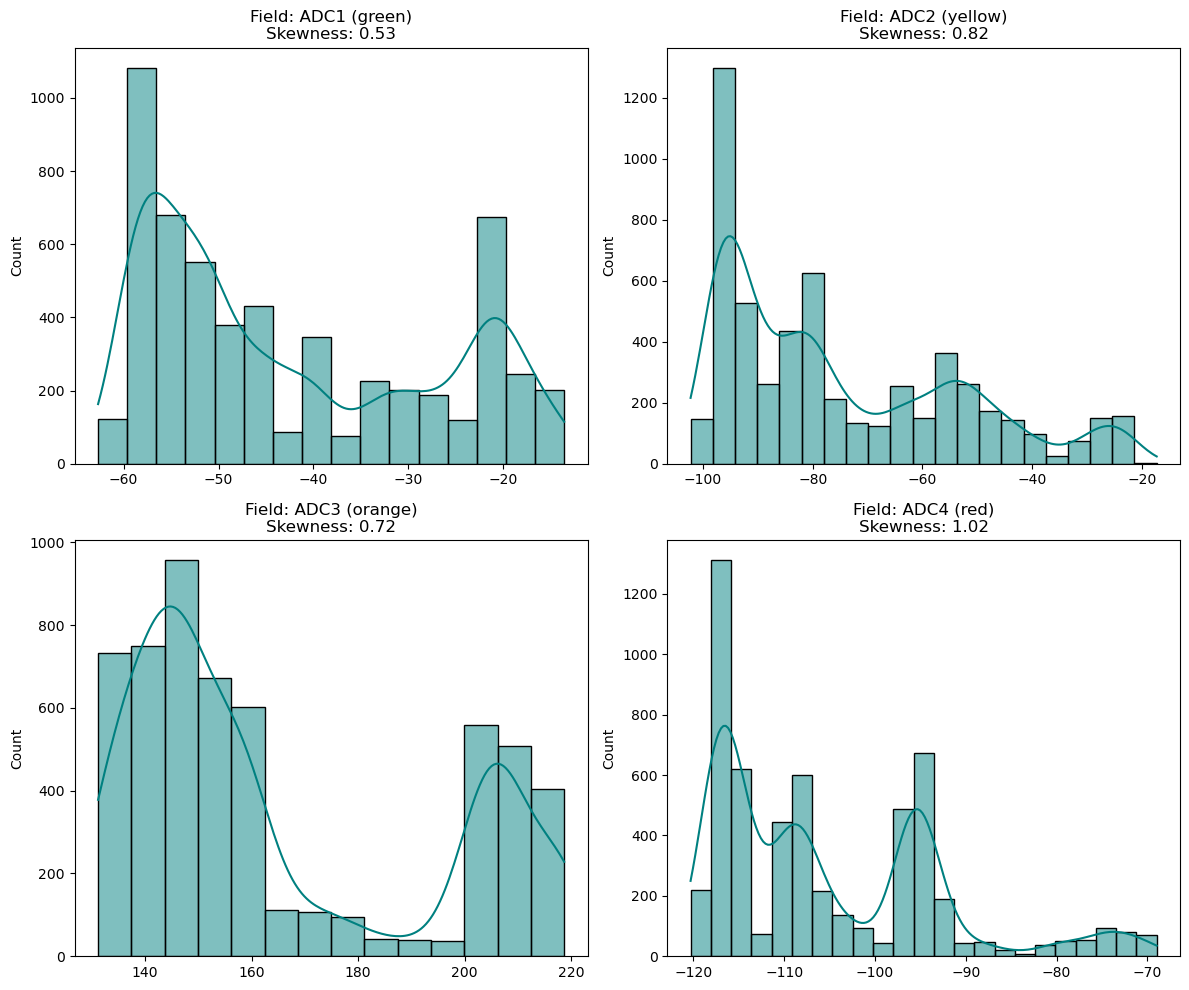

In [15]:
# 1. Set the canvas to 2 rows and 2 columns.
fig, axes = plt.subplots(2, 2, figsize=(12, 10))
axes = axes.flatten()  # Flatten the 2x2 matrix to make it easier to draw using loops.
plt.savefig('distribution_plot.png')
# 2. Loop through the column names to draw the graph
cols = ['ADC1 (green)', 'ADC2 (yellow)', 'ADC3 (orange)', 'ADC4 (red)']  # Make sure the df only has those 4 columns.
for i, col in enumerate(cols):
    # Draw a histogram and kernel density curve (KDE).
    sns.histplot(df1[col], kde=True, ax=axes[i], color='teal')
    
    # Get the skewness value of this column
    col_skew = df1[col].skew()
    
    # Set a title to directly display the skewness value.
    axes[i].set_title(f'Field: {col}\nSkewness: {col_skew:.2f}')
    axes[i].set_xlabel('')

# 3. Automatically adjust layout to prevent title overlap
plt.tight_layout()

This indicates that the signal is "stable with low fluctuations" most of the time.

However: Occasionally, "large voltage spikes" occur.  

KDE curve: Overall distribution trend (similar to probability density)

These extreme values likely correspond to biologically meaningful spike events rather than noise.

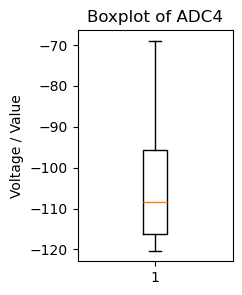

In [16]:
# Draw boxplot
plt.figure(figsize=(2, 3)) # Box plots - a narrower and taller shape.
plt.boxplot(df1["ADC4 (red)"]) # .dropna() Exclude missing values ​​to prevent errors.

plt.title("Boxplot of ADC4")
plt.ylabel("Voltage / Value")
plt.show()

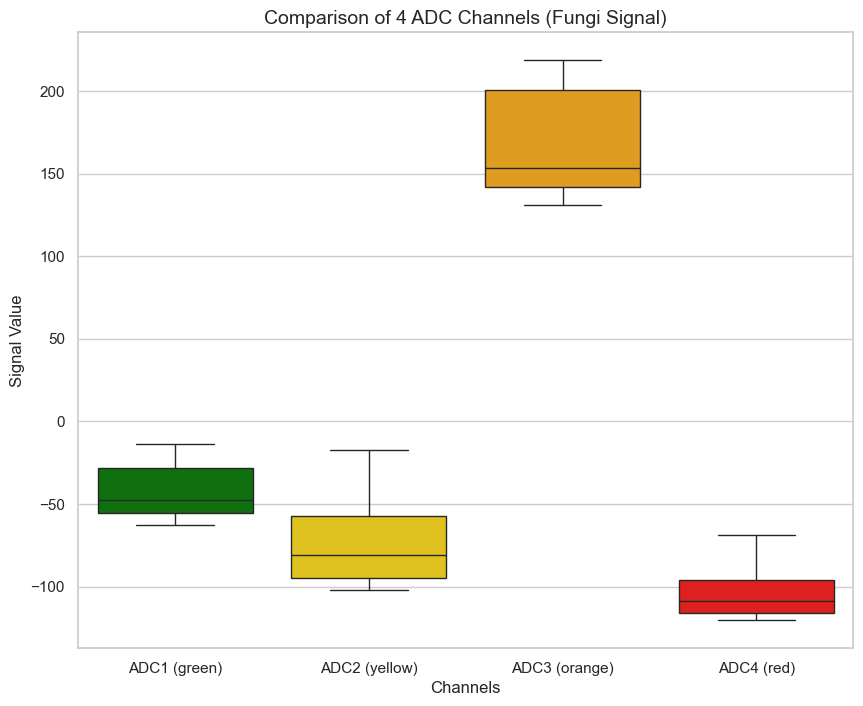

In [17]:
# Set plot style
sns.set_theme(style="whitegrid")

# 1. Create a large canvas (make it wider for easier comparison).
plt.figure(figsize=(10, 8))

# 2. Select the 4 columns of data - want to plot
# Note: The column names must be exactly the same as those in df1.
cols = ["ADC1 (green)", "ADC2 (yellow)", "ADC3 (orange)", "ADC4 (red)"]

# 3. Pass in these columns of the entire DataFrame directly.

# Palette set the color scheme; use specific colors to correspond to column names.
sns.boxplot(data=df1[cols], palette=["green", "gold", "orange", "red"])

# 4. Add labels
plt.title("Comparison of 4 ADC Channels (Fungi Signal)", fontsize=14)
plt.ylabel("Signal Value")
plt.xlabel("Channels")

plt.show()

The distribution plots show a positively skewed pattern, where most signal values are concentrated within a lower amplitude range, while a smaller number of high-amplitude values form a long right tail.

These high-value observations are not treated as noise, but are likely indicative of biologically meaningful spike events in fungal electrical activity.

Those 4 ADCs might have different locations, hardware bias, and contact resistances.
<img src="IMG_4592.jpeg" width="400">  
The observed differences between the four ADC channels are primarily attributed to experimental and hardware factors rather than biological variation in the fungus.

From the hardware setup, electrode placement varies across channels in terms of depth, position, and contact quality with the fungal tissue. These variations can significantly affect the measured baseline voltage and signal amplitude.

Additionally, differences in electrode contact resistance, wiring configuration, and potential channel-specific bias in the ADC system may introduce offsets and variability across channels.

Therefore, direct comparison of raw signal values across channels is not meaningful without preprocessing. Baseline correction techniques such as mean-centering or detrending are required before analyzing patterns in the fungal bioelectrical signals.

<br> 1. Baseline Difference (Channel Offset) <br>

ADC3 exhibits a significantly higher baseline compared to the other channels, which remain in the negative range.

This difference is unlikely to reflect biological variation in the fungus, but is more plausibly attributed to electrode-specific factors such as contact resistance, electrode placement, or hardware bias.

To enable meaningful cross-channel comparison, it is necessary to apply baseline correction (e.g., mean-centering or detrending) to each channel prior to further analysis.

<br> 2. Signal Fluctuation (Variability Across Channels) <br>

ADC3 shows the largest variability among all channels, as indicated by its wider interquartile range and longer whiskers in the boxplot.

This suggests that the signal recorded at this electrode location exhibits greater amplitude variation.

However, this increased variability may be influenced by either biological activity or external factors such as noise, electrode placement, or environmental interference, and cannot be solely attributed to fungal activity without further temporal analysis.

<br> 3. Observations Regarding Spikes <br>

The boxplots show few statistical outliers beyond the whiskers, indicating that extreme values are not highly isolated.

However, this does not imply the absence of spike-like activity. Boxplots are not sensitive to temporal dynamics and may fail to capture transient events such as spikes.

To accurately assess the presence of spikes, time-series analysis is required.

<br> 4. Distribution Symmetry <br>

In ADC2 and ADC4, the median appears slightly shifted within the box, suggesting a degree of asymmetry in the signal distribution.

This indicates that the signal values are not evenly distributed around the central tendency.

However, further analysis is required to determine whether this asymmetry corresponds to biologically meaningful signal patterns, such as directional electrical activity.

---

# III. Exploratory Data Analysis with biologically meaningful spike
## 3.1 Visualize data

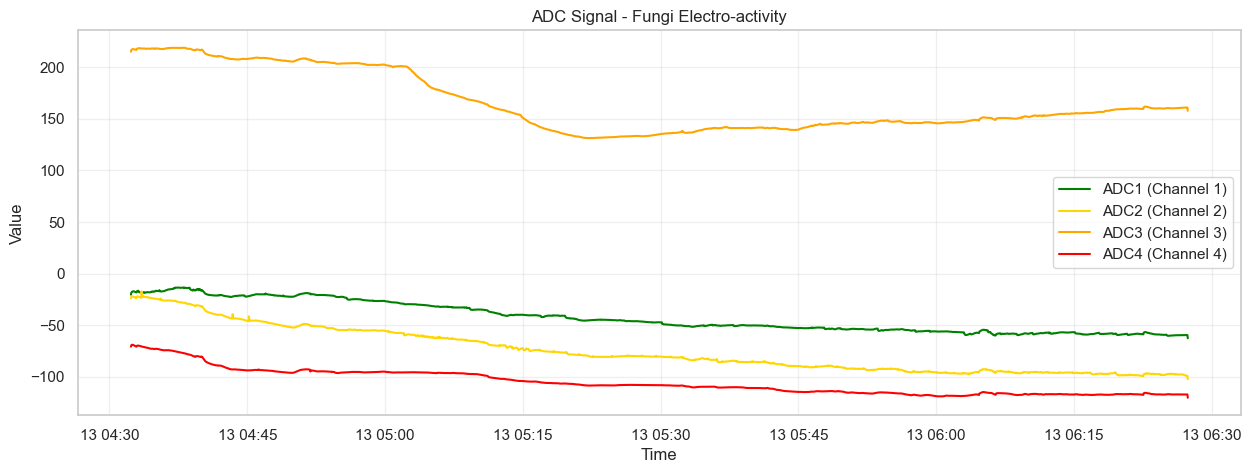

In [18]:
plt.figure(figsize=(15, 5)) # set wider plot

# 1. Add labels and colors
plt.plot(df1["ADC1 (green)"], color='green', label="ADC1 (Channel 1)")
plt.plot(df1["ADC2 (yellow)"], color='gold',  label="ADC2 (Channel 2)")
plt.plot(df1["ADC3 (orange)"], color='orange', label="ADC3 (Channel 3)")
plt.plot(df1["ADC4 (red)"],    color='red',    label="ADC4 (Channel 4)")

plt.title("ADC Signal - Fungi Electro-activity")
plt.xlabel("Time")
plt.ylabel("Value")

# 2. show legend 
plt.legend() 
# Set outside legend, not influence curves
# plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')

plt.grid(True, alpha=0.3) # grid helps see fluctuations
plt.show()

The data cannot be used directly because:
- The baselines are different;
- The channels are not comparable.  

Detrend is a essential and necessary step.

signal = baseline + patterns  

baseline: is not patterns
- Electrode deviation
- Battery variation
- Temperature
- Contact variation
- Humidity  
---
<a id="10"></a>
## 3.2 Time series analysis-Normalization

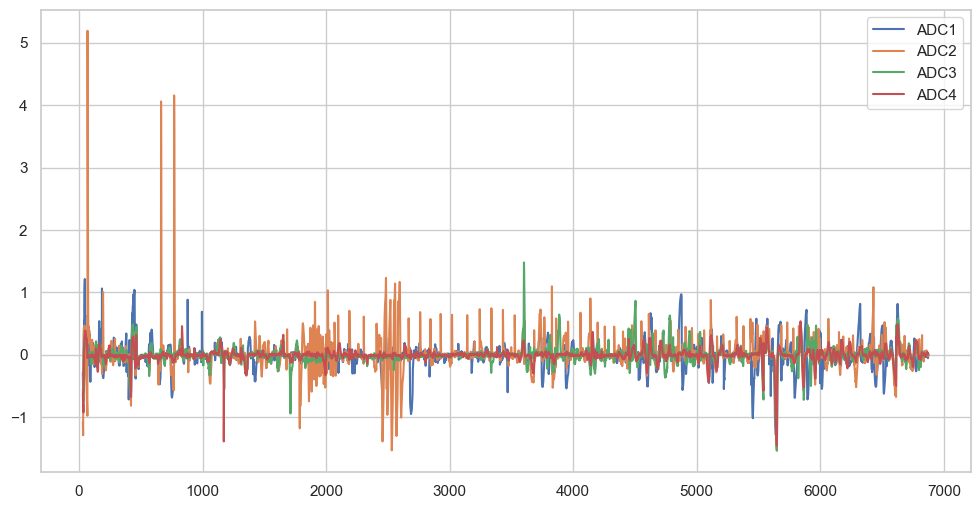

In [19]:
# Normalization: Subtracting the mean to center the data around 0.
cols = ["ADC1 (green)", "ADC2 (yellow)", "ADC3 (orange)", "ADC4 (red)"]

for col in cols:
    # df1[col] = df1[col] - df1[col].mean()
    df1[col] = df1[col] - df1[col].rolling(window=50, center=True).median()  # better remove baseline

plt.figure(figsize=(12,6))
plt.plot(df1['elapsed_time'], df1["ADC1 (green)"], label='ADC1')
plt.plot(df1['elapsed_time'], df1["ADC2 (yellow)"], label='ADC2')
plt.plot(df1['elapsed_time'], df1["ADC3 (orange)"], label='ADC3')
plt.plot(df1['elapsed_time'], df1["ADC4 (red)"], label='ADC4')
plt.legend()
plt.show()

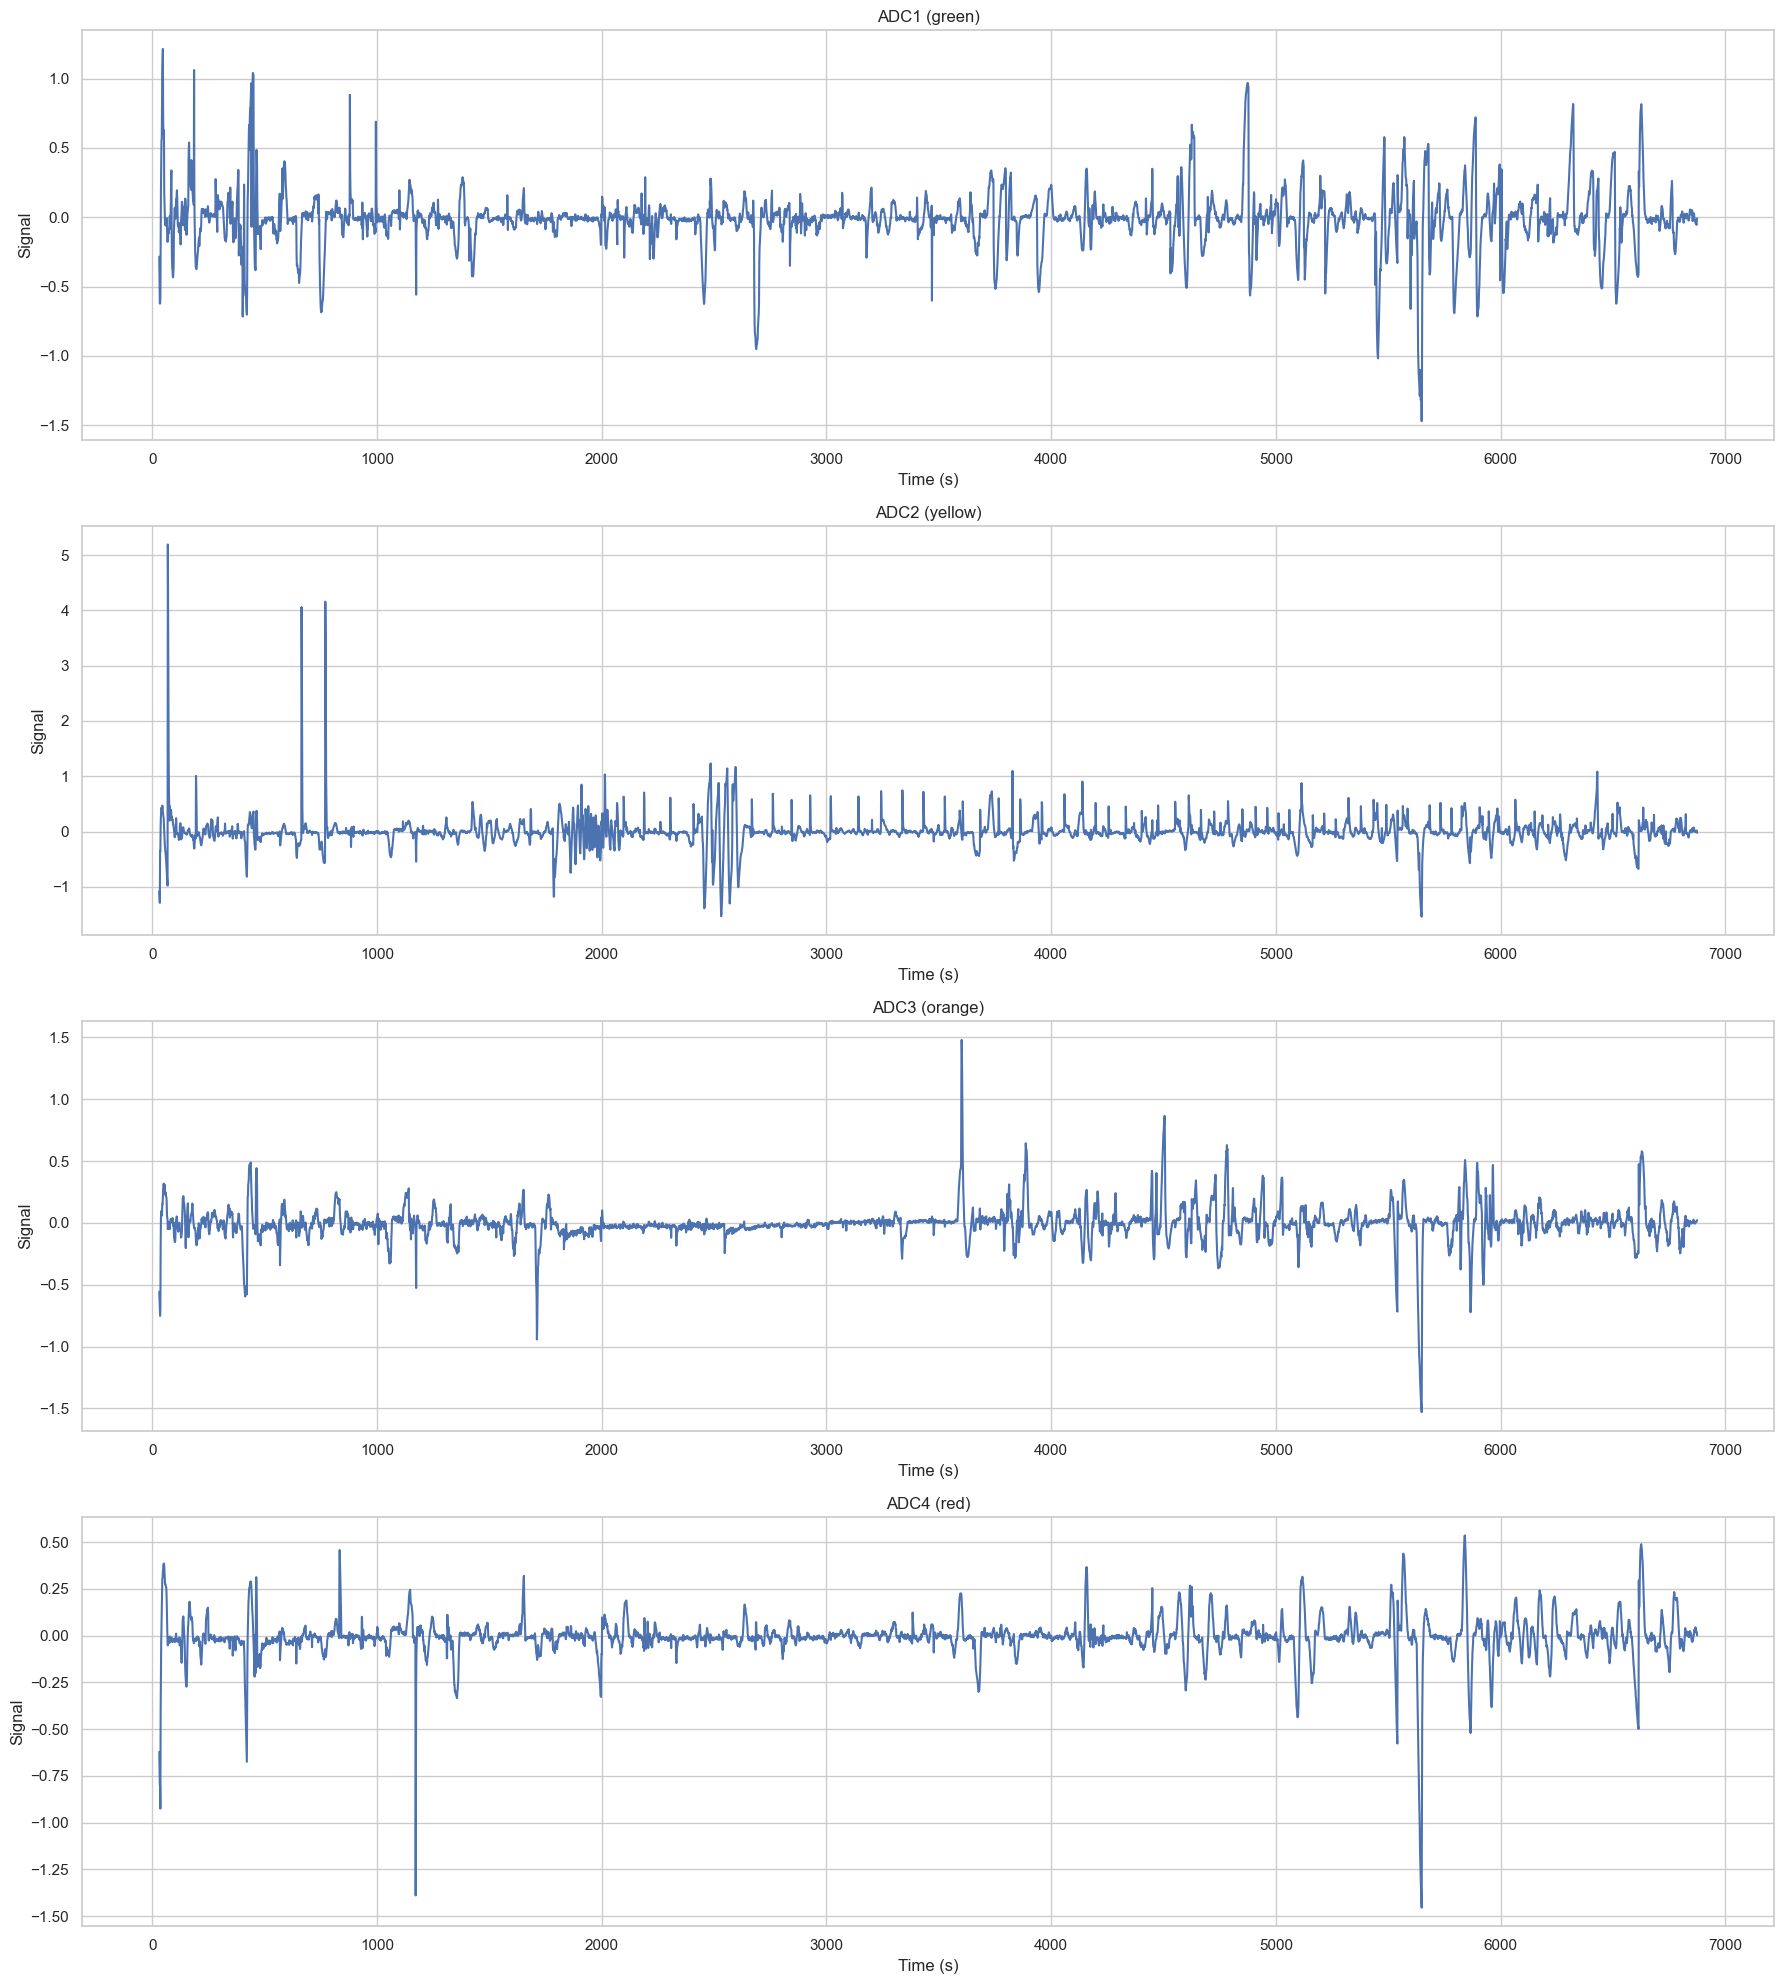

<Figure size 640x480 with 0 Axes>

In [20]:
# fig, axes = plt.subplots(2, 2, figsize=(14, 8))
# axes = axes.flatten()

fig, axes = plt.subplots(4, 1, figsize=(18, 20)) 
for i, col in enumerate(cols):
    axes[i].plot(df1['elapsed_time'], df1[col])
    axes[i].set_title(col)
    axes[i].set_xlabel('Time (s)')
    axes[i].set_ylabel('Signal')

# Automatically adjust layout (to prevent overlap)
plt.tight_layout()
plt.show()

plt.savefig('No_prenormalization.png')

No obvious periodicity  

Overall fluctuations around 0 (indicating successful detrend)  

The fluctuations are:
- Random
- Irregular
- No repeating pattern. 
---

## 3.3 Spike Detection
<a id="11"></a>
Want: 
- Spike Quantity
- Spike Frequency
- Spike Distribution

Method 1: use absolute value--but spike may up or down  
Method 2: use rolling - automatic adaptive - depends on Normal Distribution  
Method 3: use percentile - not depend on Normal Distribution

#### Try 3
A threshold-based spike detection method was applied using the 3-sigma rule, where values exceeding three standard deviations from the mean were classified as spike events.  

This approach assumes that most signal values lie within a normal range, and extreme deviations correspond to transient spike-like activity.  

To improve robustness for non-Gaussian signals, alternative methods such as rolling statistics and percentile-based thresholds may also be considered.  

In [21]:
threshold = df1["ADC1 (green)"].quantile(0.99)
df1['spike'] = df1["ADC1 (green)"] > threshold

print(df1['spike'])

Time
2026-03-13 04:32:20.310    False
2026-03-13 04:32:21.543    False
2026-03-13 04:32:22.772    False
2026-03-13 04:32:24.001    False
2026-03-13 04:32:25.230    False
                           ...  
2026-03-13 06:27:19.439    False
2026-03-13 06:27:20.668    False
2026-03-13 06:27:21.899    False
2026-03-13 06:27:23.128    False
2026-03-13 06:27:24.357    False
Name: spike, Length: 5615, dtype: bool


There are many False, so that spike has not been catched.

In [22]:
print(threshold)
print(df1["ADC1 (green)"].max())
df1['spike'].value_counts()

0.6625363499999992
1.2139890000000015


spike
False    5559
True       56
Name: count, dtype: int64

99% of the values ​​are ≤ 0.6569. Only 1% of the values ​​are > 0.6569.  
Max value: 1.0284

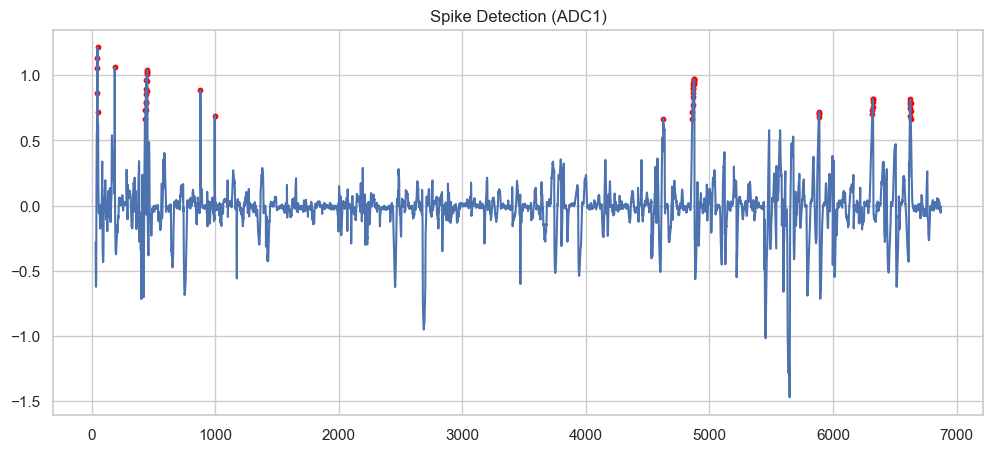

spike
False    5559
True       56
Name: count, dtype: int64


In [23]:
# plot red point as detected spikes
col = "ADC1 (green)"

plt.figure(figsize=(12,5))
plt.plot(df1['elapsed_time'], df1[col])

plt.scatter(df1['elapsed_time'][df1['spike']],
            df1[col][df1['spike']],
            color='red', s=10)

plt.title("Spike Detection (ADC1)")
plt.show()

print(df1['spike'].value_counts())

The percentile-based method identifies the most extreme signal values; however, these may not necessarily correspond to biologically meaningful spike events.

Given the relatively low amplitude and continuous nature of the signal, the detected spikes may reflect statistical extremes rather than distinct electrophysiological events.

99% lost medium spike, but not all spike patterns only positive.

#### Try Absolute
Find Positive and Negative

In [24]:
threshold = df1[col].quantile(0.99) 
df1['spike'] = abs(df1[col]) > threshold  # use absolute to get positive and negative spikes
print(df1['spike'])

Time
2026-03-13 04:32:20.310    False
2026-03-13 04:32:21.543    False
2026-03-13 04:32:22.772    False
2026-03-13 04:32:24.001    False
2026-03-13 04:32:25.230    False
                           ...  
2026-03-13 06:27:19.439    False
2026-03-13 06:27:20.668    False
2026-03-13 06:27:21.899    False
2026-03-13 06:27:23.128    False
2026-03-13 06:27:24.357    False
Name: spike, Length: 5615, dtype: bool


In [25]:
print(df1['spike'].value_counts())

spike
False    5504
True      111
Name: count, dtype: int64


Now 104 or 111 spikes are detected. More than last attempt👍

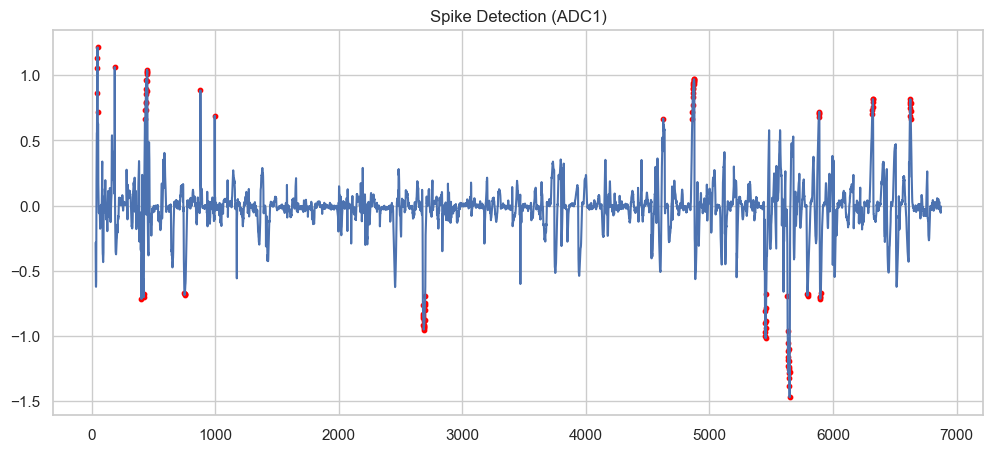

In [26]:
# Plot
col = "ADC1 (green)"

plt.figure(figsize=(12,5))
plt.plot(df1['elapsed_time'], df1[col])

plt.scatter(df1['elapsed_time'][df1['spike']],
            df1[col][df1['spike']],
            color='red', s=10)

plt.title("Spike Detection (ADC1)")
plt.show()

---
#### Try 0.96 percentile


In [27]:
threshold = df1[col].quantile(0.95) 
df1['spike'] = abs(df1[col]) > threshold  # use absolute to get positive and negative spikes
print(df1['spike'])

Time
2026-03-13 04:32:20.310    False
2026-03-13 04:32:21.543    False
2026-03-13 04:32:22.772    False
2026-03-13 04:32:24.001    False
2026-03-13 04:32:25.230    False
                           ...  
2026-03-13 06:27:19.439    False
2026-03-13 06:27:20.668    False
2026-03-13 06:27:21.899    False
2026-03-13 06:27:23.128    False
2026-03-13 06:27:24.357    False
Name: spike, Length: 5615, dtype: bool


In [28]:
print(df1['spike'].value_counts())

spike
False    4952
True      663
Name: count, dtype: int64


663 spikes are detected.

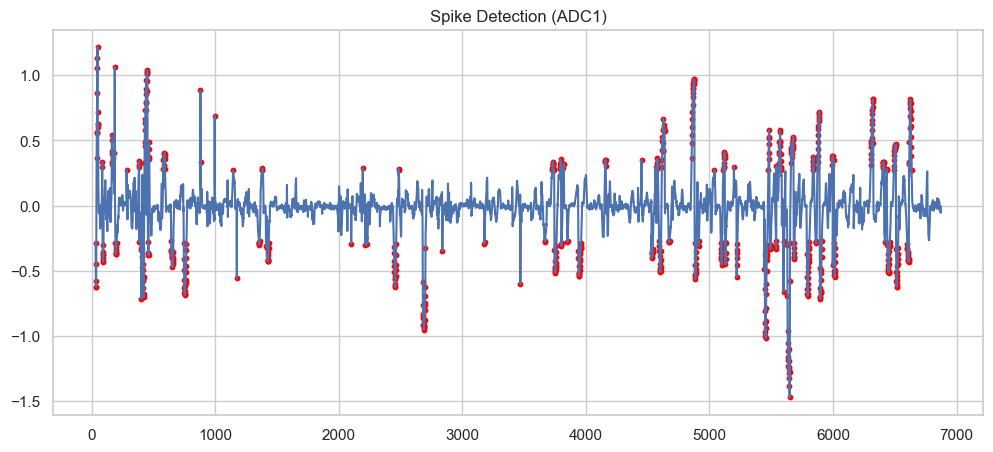

In [29]:
# Plot
col = "ADC1 (green)"

plt.figure(figsize=(12,5))
plt.plot(df1['elapsed_time'], df1[col])

plt.scatter(df1['elapsed_time'][df1['spike']],
            df1[col][df1['spike']],
            color='red', s=10)

plt.title("Spike Detection (ADC1)")
plt.show()

Both positive and negative spikes can be detected.

--- 
#### Try2 

In [30]:
# Method 3 - try lower quantile
threshold = df1["ADC1 (green)"].quantile(0.95)
# threshold = df1["ADC1 (green)"].std() * 2

# col = "ADC1 (green)"

# rolling_mean = df1[col].rolling(50, center=True).mean()
# rolling_std = df1[col].rolling(50, center=True).std()

# df1['spike'] = abs(df1[col] - rolling_mean) > 2 * rolling_std
# df1['spike'] = df1['spike'].fillna(False)

df1['spike'] = df1["ADC1 (green)"] > threshold

print(df1['spike'])

df1['spike'].value_counts()

Time
2026-03-13 04:32:20.310    False
2026-03-13 04:32:21.543    False
2026-03-13 04:32:22.772    False
2026-03-13 04:32:24.001    False
2026-03-13 04:32:25.230    False
                           ...  
2026-03-13 06:27:19.439    False
2026-03-13 06:27:20.668    False
2026-03-13 06:27:21.899    False
2026-03-13 06:27:23.128    False
2026-03-13 06:27:24.357    False
Name: spike, Length: 5615, dtype: bool


spike
False    5336
True      279
Name: count, dtype: int64

Result: found 279 spikes.

---

# 4. Correlation

In [31]:
print(df1.columns.tolist())

['ADC1 (green)', 'ADC2 (yellow)', 'ADC3 (orange)', 'ADC4 (red)', 'elapsed_time', 'spike']


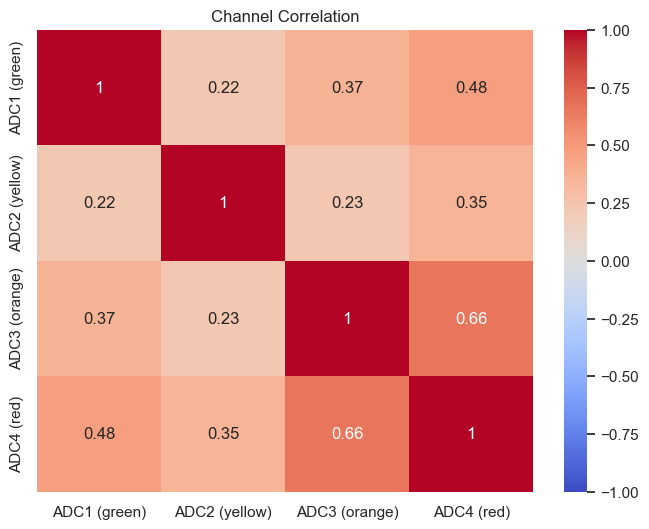

In [32]:
cols = ['ADC1 (green)', 'ADC2 (yellow)', 'ADC3 (orange)', 'ADC4 (red)']

corr = df1[cols].corr(method="pearson")

plt.figure(figsize=(8,6))
sns.heatmap(corr, annot=True, cmap="coolwarm", vmin=-1, vmax=1)
plt.title("Channel Correlation")
plt.show()

In [33]:
print(df2.columns.tolist())

['index', 'date', 'time (from start)', 'Normalized data', 'N5616 Trace1', 'N5616 Trace2', 'N5616 Trace3', 'N5616 Trace4', 'Detrend', 'Min index row', 'max index row', 'D21 Trace1', 'D21 Trace2', 'D21 Trace3', 'D21 Trace4', 'offset', 0, 1, 2, 3]


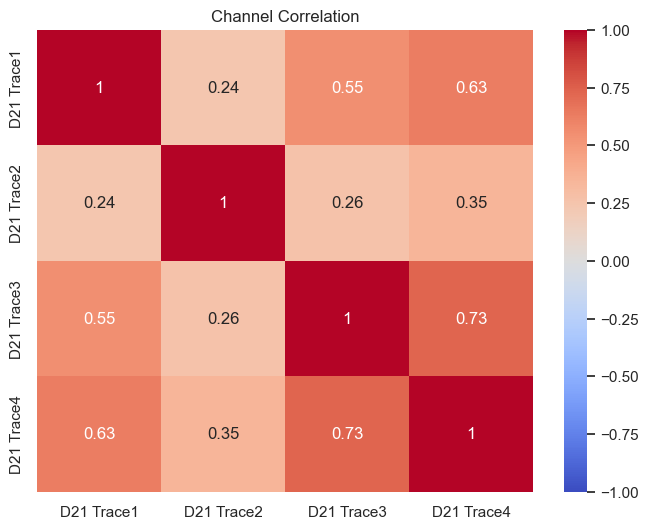

In [34]:
cols = ["D21 Trace1","D21 Trace2","D21 Trace3","D21 Trace4"]

corr = df2[cols].corr(method="pearson")

plt.figure(figsize=(8,6))
sns.heatmap(corr, annot=True, cmap="coolwarm", vmin=-1, vmax=1)
plt.title("Channel Correlation")
plt.show()

The four channels are positively correlated, and the channels are not independent noise, but rather share a common trend of change.  
-> support fungi network electrical coupling / shared response
  
ADC3 and ADC4 Strongly correlated: may be spatially close, share a signal source, or respond together in the same physiological process.

---

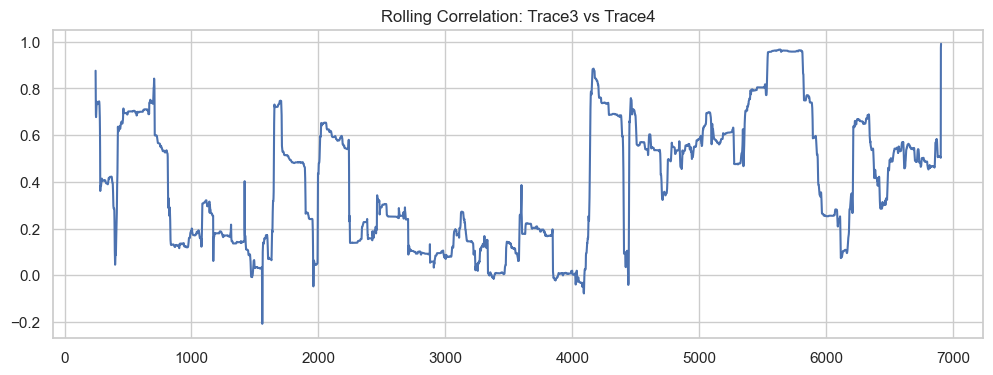

In [35]:
# Rolling correlation - detrend data
rolling_corr = df2["D21 Trace3"].rolling(200).corr(df2["D21 Trace4"])

plt.figure(figsize=(12,4))
plt.plot(df2[time_col], rolling_corr)
plt.title("Rolling Correlation: Trace3 vs Trace4")
plt.show()

The coupling relationship changes in different time periods and different regions.  
Positive: Trace3 +, Trace4 +
Negative: Trace3 +,  Trace4-

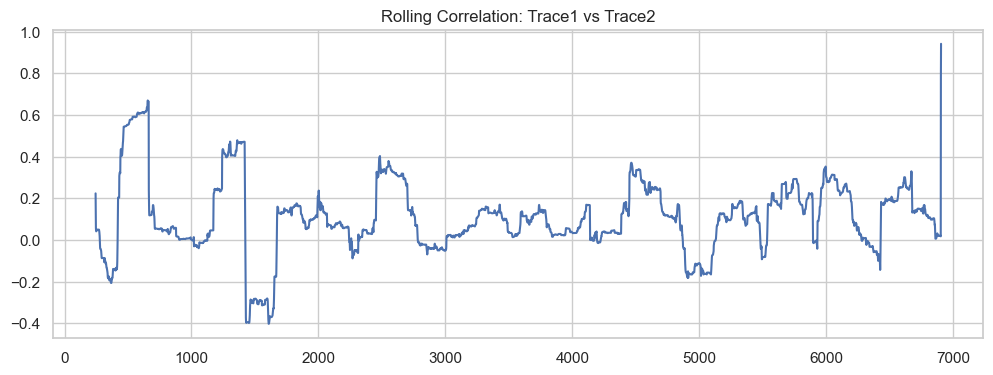

In [36]:
# Rolling correlation - detrend data
rolling_corr = df2["D21 Trace1"].rolling(200).corr(df2["D21 Trace2"])

plt.figure(figsize=(12,4))
plt.plot(df2[time_col], rolling_corr)
plt.title("Rolling Correlation: Trace1 vs Trace2")
plt.show()

Trace 1 and Trace2 has bigger negative correlation.

---

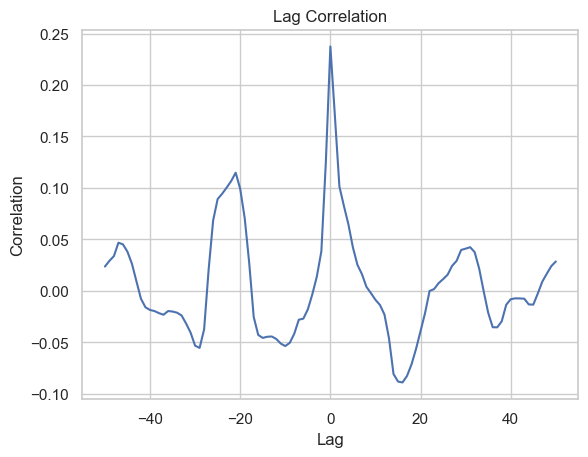

In [37]:
# Lag Correlation - detrend data
lags = range(-50,51)
corrs = []

x = df2["D21 Trace1"].values
y = df2["D21 Trace2"].values

for lag in lags:
    if lag < 0:
        c = np.corrcoef(x[:lag], y[-lag:])[0,1]
    elif lag > 0:
        c = np.corrcoef(x[lag:], y[:-lag])[0,1]
    else:
        c = np.corrcoef(x, y)[0,1]
    corrs.append(c)

plt.plot(lags, corrs)
plt.title("Lag Correlation")
plt.xlabel("Lag")
plt.ylabel("Correlation")
plt.show()

Trace1 and Trace2 change almost at same time.

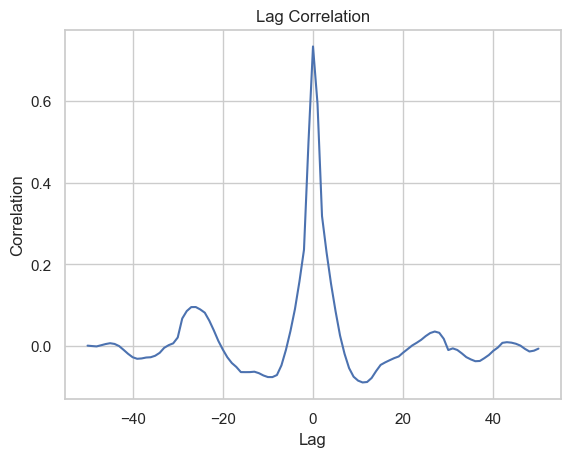

In [38]:
# Lag Correlation - detrend data
lags = range(-50,51)
corrs = []

x = df2["D21 Trace3"].values
y = df2["D21 Trace4"].values

for lag in lags:
    if lag < 0:
        c = np.corrcoef(x[:lag], y[-lag:])[0,1]
    elif lag > 0:
        c = np.corrcoef(x[lag:], y[:-lag])[0,1]
    else:
        c = np.corrcoef(x, y)[0,1]
    corrs.append(c)

plt.plot(lags, corrs)
plt.title("Lag Correlation")
plt.xlabel("Lag")
plt.ylabel("Correlation")
plt.show()

Trace3 and Trace4 change almost at same time.

---

# 5. Regression

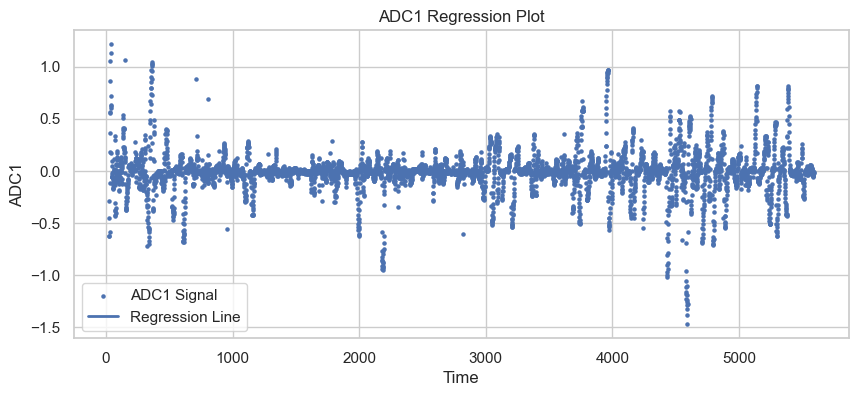

In [39]:
# Regression Plot
y = df1["ADC1 (green)"].values
x = np.arange(len(y))

# Perform linear regression (fit a straight line)
coef = np.polyfit(x, y, 1)
y_pred = np.polyval(coef, x)

plt.figure(figsize=(10,4))
plt.scatter(x, y, s=5, label="ADC1 Signal")
plt.plot(x, y_pred, linewidth=2, label="Regression Line")

plt.title("ADC1 Regression Plot")
plt.xlabel("Time")
plt.ylabel("ADC1")
plt.legend()
plt.show()

---

# Use normalized data to clustering  
windowing + feature extraction + clustering

In [40]:
from scipy.signal import find_peaks
from scipy.fft import rfft, rfftfreq

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score

In [41]:
print(df2.columns)
print(df2.head())

Index([            'index',              'date', 'time (from start)',
         'Normalized data',      'N5616 Trace1',      'N5616 Trace2',
            'N5616 Trace3',      'N5616 Trace4',           'Detrend',
           'Min index row',     'max index row',        'D21 Trace1',
              'D21 Trace2',        'D21 Trace3',        'D21 Trace4',
                  'offset',                   0,                   1,
                         2,                   3],
      dtype='object')
   index        date  time (from start) Normalized data  N5616 Trace1  \
0      1  2026-03-13              0.000               N     26.909180   
1      2         NaN              1.233             NaN     28.104493   
2      3         NaN              2.462             NaN     28.828369   
3      4         NaN              3.691             NaN     29.210450   
4      5         NaN              4.920             NaN     29.340576   

   N5616 Trace2  N5616 Trace3  N5616 Trace4        Detrend  Min index

In [42]:
df2.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5615 entries, 0 to 5614
Data columns (total 20 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   index              5615 non-null   int64  
 1   date               1 non-null      object 
 2   time (from start)  5615 non-null   float64
 3   Normalized data    3 non-null      object 
 4   N5616 Trace1       5615 non-null   float64
 5   N5616 Trace2       5615 non-null   float64
 6   N5616 Trace3       5615 non-null   float64
 7   N5616 Trace4       5615 non-null   float64
 8   Detrend            7 non-null      object 
 9   Min index row      5615 non-null   int64  
 10  max index row      5615 non-null   int64  
 11  D21 Trace1         5615 non-null   float64
 12  D21 Trace2         5615 non-null   float64
 13  D21 Trace3         5615 non-null   float64
 14  D21 Trace4         5615 non-null   float64
 15  offset             0 non-null      float64
 16  0                  0 non

In [43]:
data = df2[[time_col] + signal_cols].dropna().copy()

time = data[time_col].values
signals = data[signal_cols].values

print("Data shape:", signals.shape)

Data shape: (5615, 4)


5615 time, 4 channels

use window to find short time shape change

In [44]:
# slide window
window_size = 60 # pattern length-> find pattern,can set 100 to find period
step_size = 20  # move
# window overlap  window - step -> pattern will not be cut

# save all window data and start 
windows = []
window_start_idx = []

# start from 0, move step_size each time and until get winodw_size
for start in range(0, len(signals) - window_size + 1, step_size):
    end = start + window_size
    windows.append(signals[start:end])
    window_start_idx.append(start)

windows = np.array(windows)   # shape: (n_windows, window_size, n_channels)

print("Windows shape:", windows.shape)

Windows shape: (278, 60, 4)


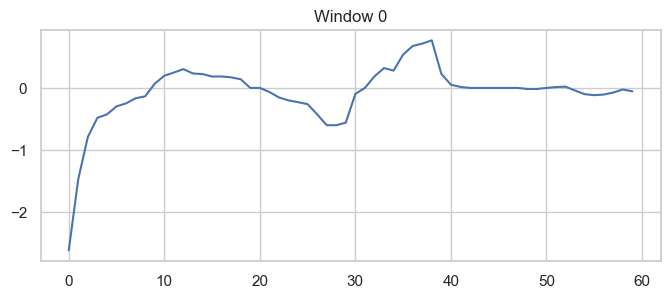

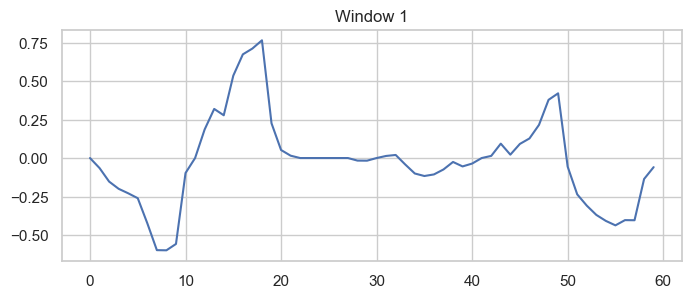

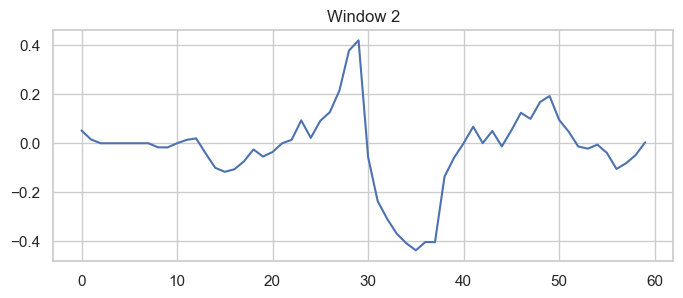

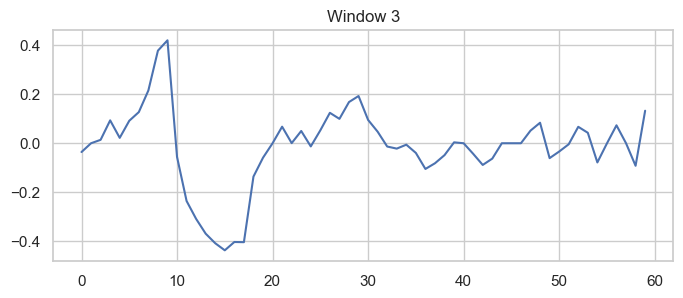

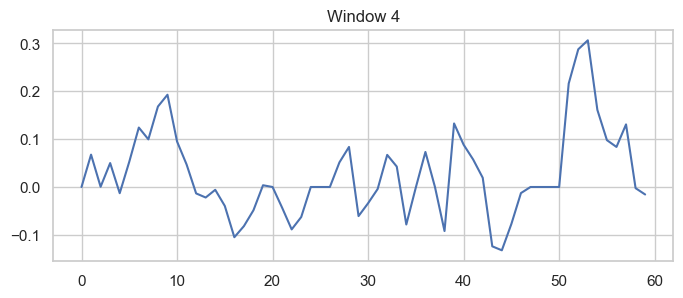

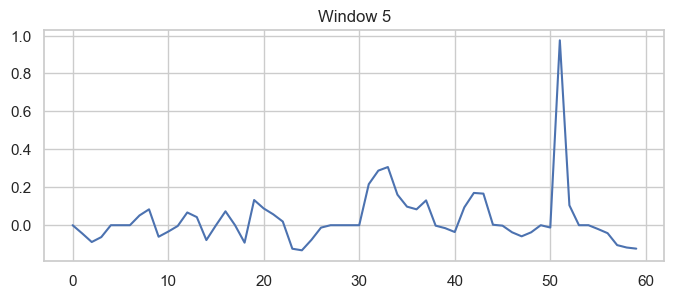

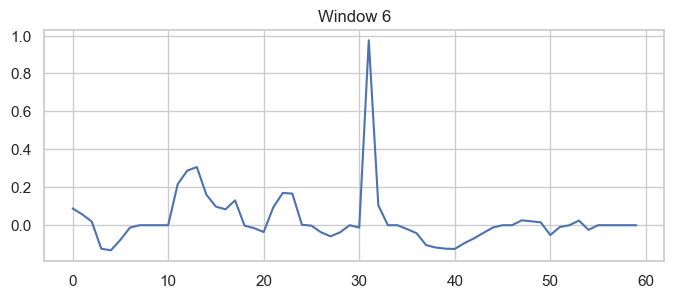

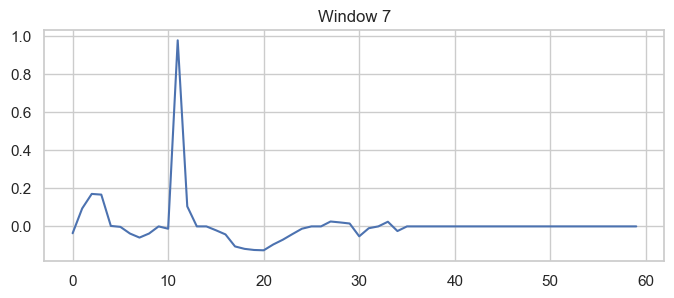

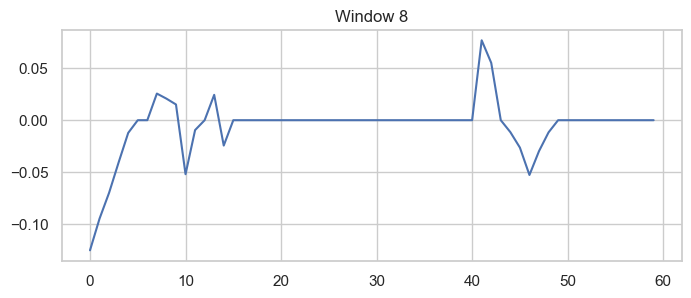

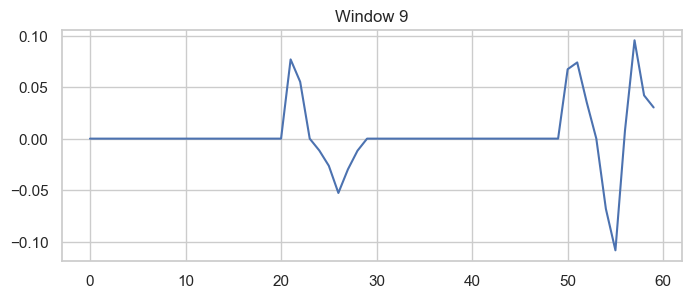

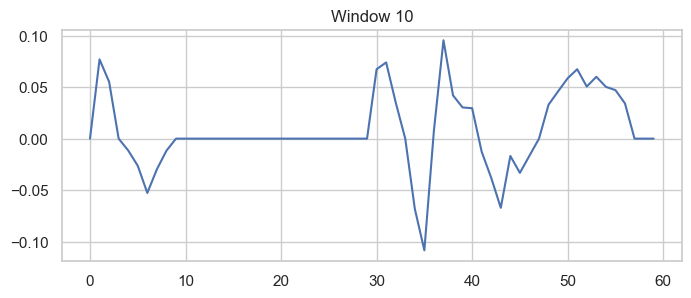

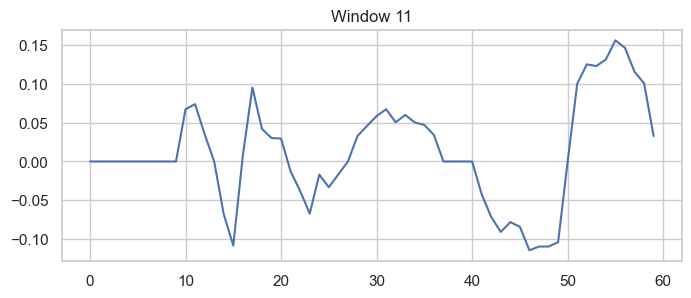

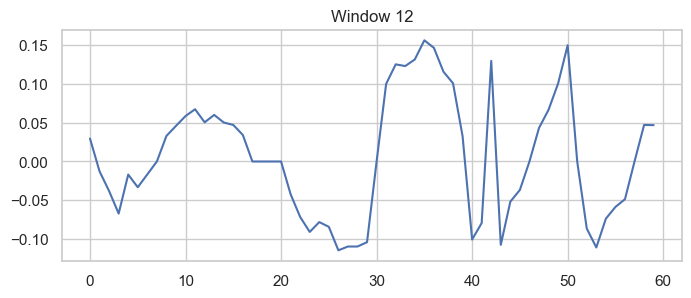

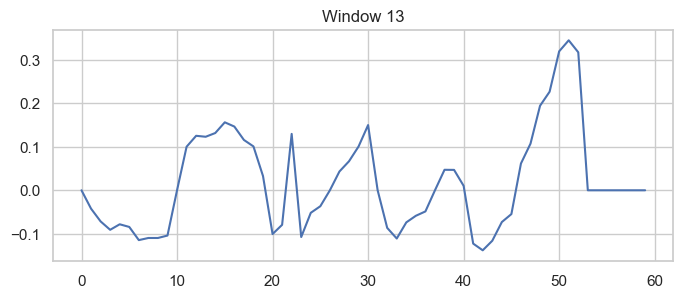

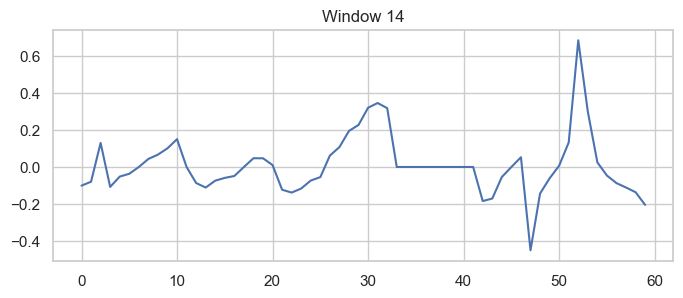

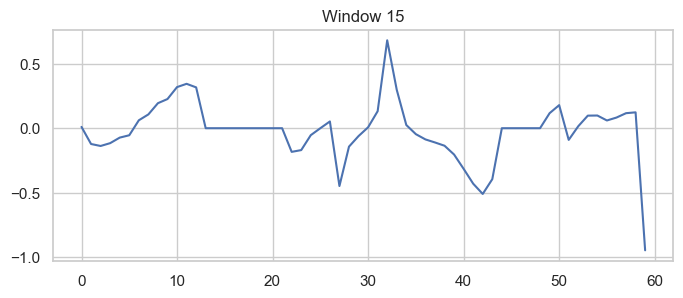

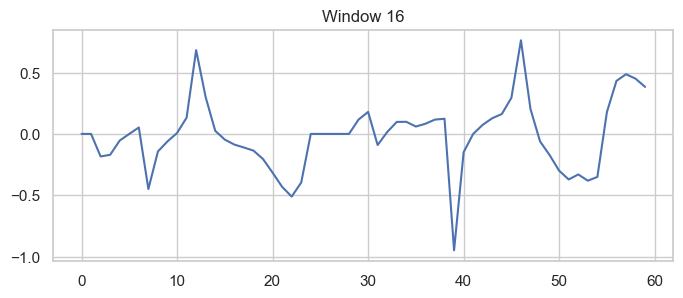

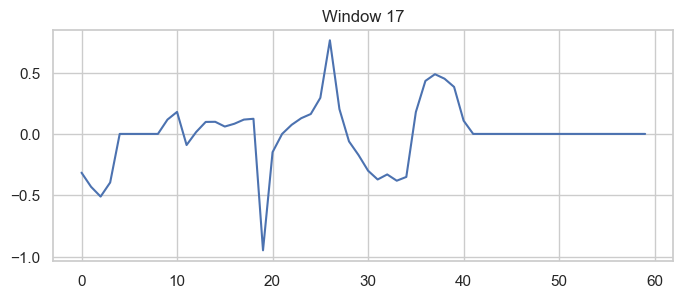

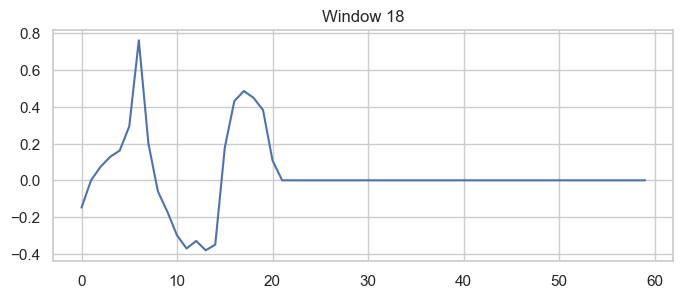

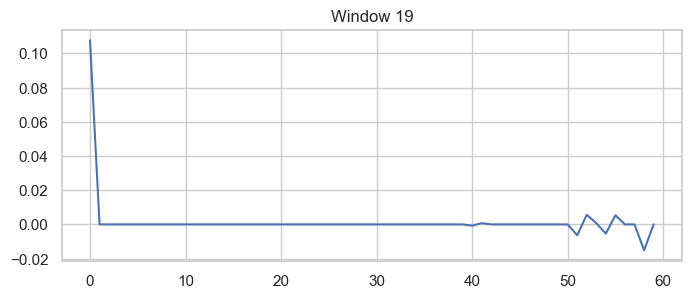

In [45]:
for i in range(20):
    plt.figure(figsize=(8,3))
    plt.plot(windows[i,:,0])
    plt.title(f"Window {i}")
    plt.show()

## Spike detection feature  
positive(+) spike：find peaks  
negative(-) spike：for -x find peaks  
threshold 用 std_multiplier * std  
prominence included，reduce small noise as spike  

In [46]:
def extract_spike_features_1d(x, distance=3, std_multiplier=2.0):
    """
    x: 1D window signal
    return: dict of spike features
    """
    x = np.asarray(x)
    
    mean_val = np.mean(x)
    std_val = np.std(x)
    
    # prevent std too small
    if std_val == 0:
        return {
            "spike_count": 0,
            "pos_spike_count": 0,
            "neg_spike_count": 0,
            "max_amplitude": 0,
            "mean_spike_height": 0,
            "mean_inter_spike_interval": 0
        }
    
    # Positive spike
    pos_peaks, pos_props = find_peaks(
        x,
        height=mean_val + std_multiplier * std_val,
        prominence=0.5 * std_val,
        distance=distance
    )
    
    # negative spike
    neg_peaks, neg_props = find_peaks(
        -x,
        height=-mean_val + std_multiplier * std_val,
        prominence=0.5 * std_val,
        distance=distance
    )
    
    pos_heights = x[pos_peaks] if len(pos_peaks) > 0 else np.array([])
    neg_heights = np.abs(x[neg_peaks]) if len(neg_peaks) > 0 else np.array([])
    
    all_spike_positions = np.sort(np.concatenate([pos_peaks, neg_peaks]))
    all_spike_heights = np.concatenate([pos_heights, neg_heights])
    
    spike_count = len(pos_peaks) + len(neg_peaks)
    pos_spike_count = len(pos_peaks)
    neg_spike_count = len(neg_peaks)
    
    if spike_count > 0:
        max_amplitude = np.max(np.abs(np.concatenate([x[pos_peaks], x[neg_peaks]])))
        mean_spike_height = np.mean(np.abs(all_spike_heights))
    else:
        max_amplitude = 0
        mean_spike_height = 0
    
    if len(all_spike_positions) >= 2:
        mean_inter_spike_interval = np.mean(np.diff(all_spike_positions))
    else:
        mean_inter_spike_interval = 0
    
    return {
        "spike_count": spike_count,
        "pos_spike_count": pos_spike_count,
        "neg_spike_count": neg_spike_count,
        "max_amplitude": max_amplitude,
        "mean_spike_height": mean_spike_height,
        "mean_inter_spike_interval": mean_inter_spike_interval
    }

## Non-Spike features 
Define single-channel ordinary statistical features + FFT features  
signal window → feature vector → clustering

Mean: represent window generally high or low   
- if mean > 0, high; if mean < 0, low

Standard deviation(std): represent fluctuation  
- small: constant
- big: strong shake and many spikes -> helpful to find active sigmal

range (amplitude range)= max - min

slope > 0, means recovery trend

energy: bigger value, higher activity

In [47]:
# preparation for clustering
def extract_basic_features_1d(x, dt=1.0):
    """
    x: 1D window signal
    dt: sampling interval
    """
    x = np.asarray(x)
    
    mean_val = np.mean(x)  
    std_val = np.std(x)  
    range_val = np.max(x) - np.min(x)
    slope_val = (x[-1] - x[0]) / len(x)
    
    # energy
    energy_val = np.sum(x ** 2)
    
    # FFT dominant frequency
    n = len(x)
    x_centered = x - np.mean(x)  # decentralize
    # transfer time signal -> frequency spectrum
    yf = np.abs(rfft(x_centered))
    xf = rfftfreq(n, d=dt)
    
    # Remove frequency 0 to prevent the dominant frequency from always being 0= remove baseline(average)
    # - use to distinguish slow or high frequency fluctuations, period pattern
    if len(yf) > 1:
        yf_no_dc = yf.copy()
        yf_no_dc[0] = 0
        dominant_freq = xf[np.argmax(yf_no_dc)] # find max frequency
    else:
        dominant_freq = 0
    
    return {
        "mean": mean_val,
        "std": std_val,
        "range": range_val,
        "slope": slope_val,
        "energy": energy_val,
        "fft_dominant_frequency": dominant_freq
    }

# Merge all features from each window.   
Extract features (4 channels) from each window and then combine them.

In [48]:
# estimate dt（time gap/interval）
if len(time) >= 2:
    dt = np.median(np.diff(time))
else:
    dt = 1.0

print("Estimated dt =", dt)

Estimated dt = 1.2290000000002692


In [49]:
def extract_window_features(window, channel_names, dt=1.0):
    """
    window shape: (window_size, n_channels)
    """
    feature_dict = {}
    
    for ch_idx, ch_name in enumerate(channel_names):
        x = window[:, ch_idx]
        
        spike_feats = extract_spike_features_1d(x, distance=3, std_multiplier=2.0)
        basic_feats = extract_basic_features_1d(x, dt=dt)
        
        # Add a prefix to each channel feature
        for k, v in spike_feats.items():
            feature_dict[f"{ch_name}_{k}"] = v
        
        for k, v in basic_feats.items():
            feature_dict[f"{ch_name}_{k}"] = v
    
    return feature_dict

In [50]:
feature_rows = []

for i, w in enumerate(windows):
    feats = extract_window_features(w, signal_cols, dt=dt)
    feats["window_id"] = i
    feats["start_idx"] = window_start_idx[i]
    feats["start_time"] = time[window_start_idx[i]]
    feature_rows.append(feats)

features_df = pd.DataFrame(feature_rows)

print(features_df.head())
print("Feature dataframe shape:", features_df.shape)

   D21 Trace1_spike_count  D21 Trace1_pos_spike_count  \
0                       0                           0   
1                       2                           1   
2                       2                           1   
3                       2                           1   
4                       1                           1   

   D21 Trace1_neg_spike_count  D21 Trace1_max_amplitude  \
0                           0                  0.000000   
1                           1                  0.764892   
2                           1                  0.437255   
3                           1                  0.437255   
4                           0                  0.306640   

   D21 Trace1_mean_spike_height  D21 Trace1_mean_inter_spike_interval  \
0                      0.000000                                   0.0   
1                      0.682129                                  10.0   
2                      0.428833                                   6.0   
3         

---

# Patterns in given datasets -- Clustering-KMeans
First, identify the possible patterns → clustering.  
Prepare the feature matrix.  
Remove non-feature columns.  

In [51]:
meta_cols = ["window_id", "start_idx", "start_time"]
feature_cols = [c for c in features_df.columns if c not in meta_cols]

X = features_df[feature_cols].values

# standardize
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

print("X_scaled shape:", X_scaled.shape)

X_scaled shape: (278, 48)


Choose k. First, look at the **silhouette score**(considerate cohesion inside of cluster, and **separation** between clusters).

In [52]:
scores = {}

for k in range(2, 7):
    km = KMeans(n_clusters=k, random_state=42, n_init=20)
    labels = km.fit_predict(X_scaled)
    score = silhouette_score(X_scaled, labels)
    scores[k] = score

print("Silhouette scores:", scores)

best_k = max(scores, key=scores.get)
print("Best k =", best_k)

Silhouette scores: {2: 0.7875692790637961, 3: 0.22241894035178592, 4: 0.1617174627732901, 5: 0.19658195572214296, 6: 0.11116657826328766}
Best k = 2


In [53]:
kmeans = KMeans(n_clusters=best_k, random_state=42, n_init=20)
cluster_labels = kmeans.fit_predict(X_scaled)

# features_df["cluster"] = cluster_labels

# print(features_df[["window_id", "start_time", "cluster"]].head())
# print(features_df["cluster"].value_counts().sort_index())

In [54]:
print(len(cluster_labels))

278


In [55]:
# features_df[features_df["cluster"] == 1]

window 0 is far away from other windows.

In [56]:
# remove the first 3 windows
features2 = features_df[features_df["window_id"] >= 3].copy()

meta_cols = ["window_id","start_idx","start_time","cluster"]
feature_cols = [c for c in features2.columns if c not in meta_cols]

X = features2[feature_cols].values
X_scaled = StandardScaler().fit_transform(X)

for k in [3,4,5]:
    km = KMeans(n_clusters=k, random_state=42, n_init=20)
    labels = km.fit_predict(X_scaled)
    print(k, pd.Series(labels).value_counts().sort_index())

3 0    219
1     50
2      6
Name: count, dtype: int64
4 0     87
1    161
2     21
3      6
Name: count, dtype: int64
5 0     81
1     16
2      6
3    153
4     19
Name: count, dtype: int64


cluster n has x clusters.

In [57]:
features_df["D21 Trace4_mean"].describe()

count    278.000000
mean       2.998440
std        0.010653
min        2.926978
25%        2.997166
50%        2.999900
75%        3.002341
max        3.032666
Name: D21 Trace4_mean, dtype: float64

In [58]:
k = 4

km = KMeans(n_clusters=k, random_state=42, n_init=20)
labels = km.fit_predict(X_scaled)

features2["cluster"] = labels

print(features2[["window_id","start_time","cluster"]].head(20))

    window_id  start_time  cluster
3           3      73.767        0
4           4      98.356        0
5           5     122.945        2
6           6     147.533        2
7           7     172.122        2
8           8     196.710        1
9           9     221.298        1
10         10     245.886        0
11         11     270.476        0
12         12     295.066        0
13         13     319.655        0
14         14     344.262        2
15         15     368.851        2
16         16     393.440        2
17         17     418.029        2
18         18     442.640        2
19         19     467.230        1
20         20     491.819        1
21         21     516.408        1
22         22     540.997        1


cluster == 0  baseline pattern  
cluster == 1  active fluctuation pattern  
cluster == 2  oscillation pattern  
cluster == 3  burst/spike pattern  

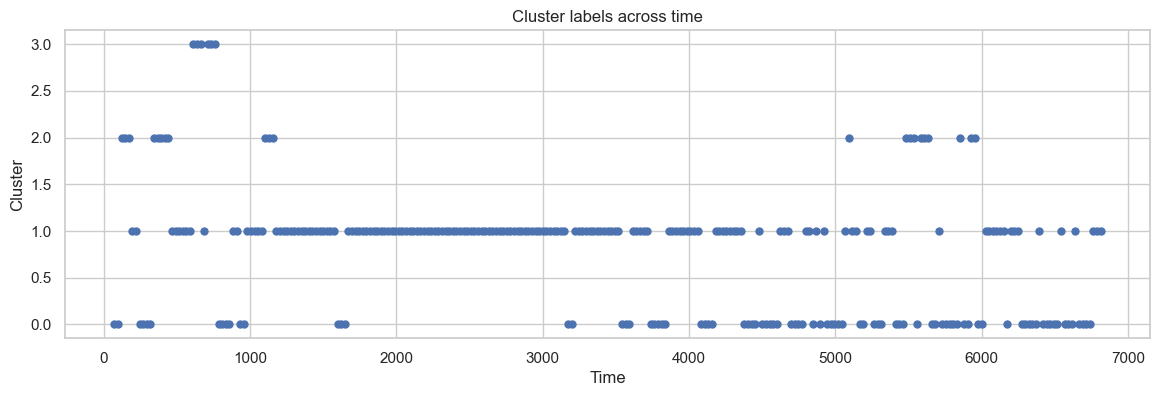

In [59]:
# Pattern Switching
plt.figure(figsize=(14,4))
plt.scatter(features2["start_time"], features2["cluster"], s=25)
plt.xlabel("Time")
plt.ylabel("Cluster")
plt.title("Cluster labels across time")
plt.show()

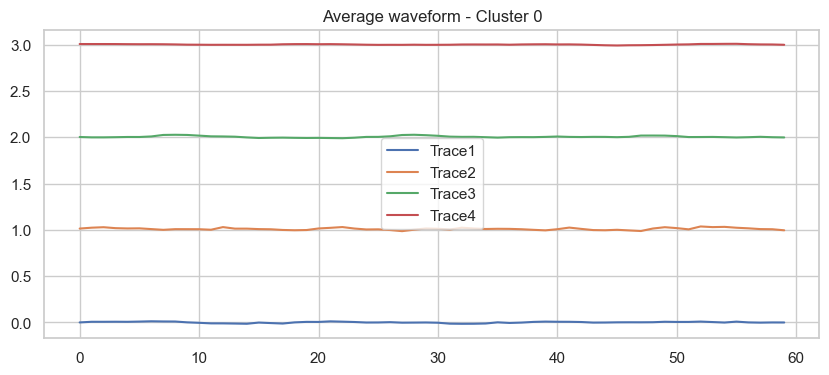

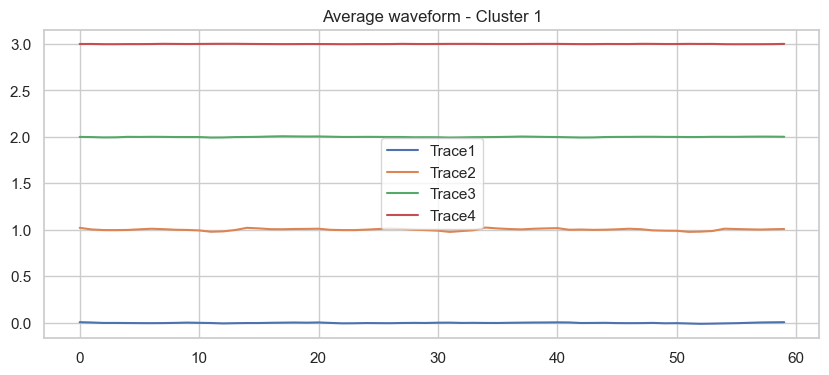

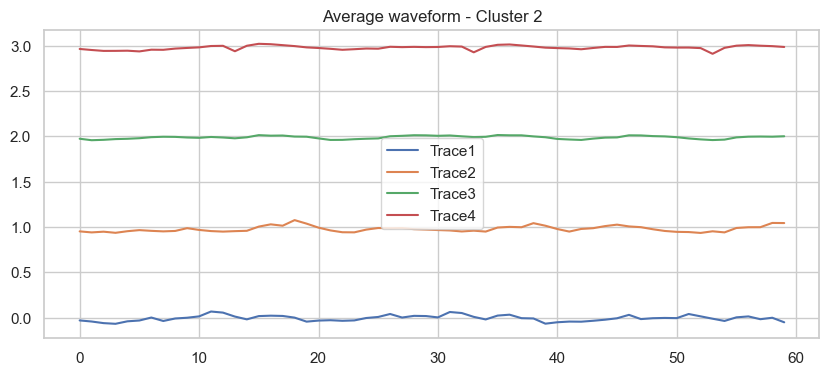

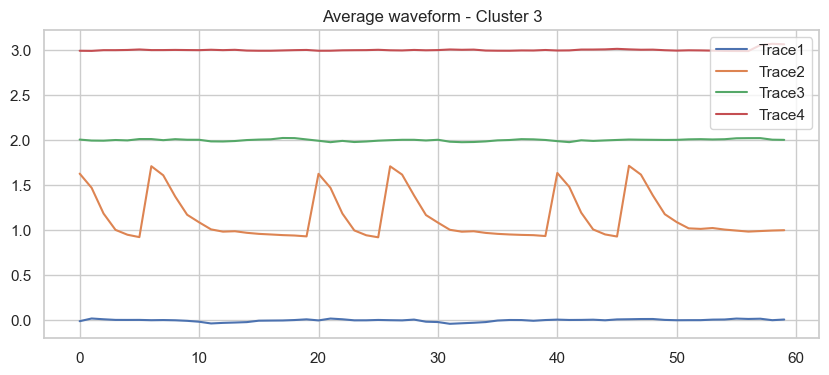

In [60]:
features2["cluster"] = labels

for c in sorted(features2["cluster"].unique()):
    
    idxs = features2.index[features2["cluster"] == c].tolist()
    
    cluster_windows = windows[idxs]
    
    mean_wave = cluster_windows.mean(axis=0)

    plt.figure(figsize=(10,4))
    
    for ch in range(4):
        plt.plot(mean_wave[:,ch], label=f"Trace{ch+1}")
    
    plt.title(f"Average waveform - Cluster {c}")
    plt.legend()
    plt.show()

Cluster 0: constant small fluctuation, aseline state
Cluster 1: Trace 2 active fluctuation state
Cluster 2: multi-channels slight fluctuation - oscillatory state
Cluster 3: Trace2 period burst/spike state
-> 4 hidden pattern candidate states

Clustering only can tell window lose to which type.
Need HMM to know:
- why switch
- next type
- Duration for one state
- Frequency for state switch

---  
# Detect patterns change and find when switch -- HMM
HMM -> know when do patterns switch

In [61]:
pip install hmmlearn

Note: you may need to restart the kernel to use updated packages.


In [62]:
from hmmlearn.hmm import GaussianHMM
import numpy as np

In [63]:
# Use feature before clustering
X_hmm = X_scaled

hmm_model = GaussianHMM(
    n_components=4,      # 4 hidden states
    covariance_type='full',
    n_iter=200,
    random_state=42
)

In [64]:
hmm_model.fit(X_hmm)

hidden_states = hmm_model.predict(X_hmm)

features2["hmm_state"] = hidden_states

Model is not converging.  Current: 8470.892587135566 is not greater than 11422.449202919011. Delta is -2951.5566157834455


In [65]:
print(len(hidden_states))

275


In [66]:
print(features2[["window_id", "start_time", "hmm_state"]].head(20))

    window_id  start_time  hmm_state
3           3      73.767          0
4           4      98.356          0
5           5     122.945          2
6           6     147.533          2
7           7     172.122          2
8           8     196.710          0
9           9     221.298          0
10         10     245.886          0
11         11     270.476          0
12         12     295.066          0
13         13     319.655          0
14         14     344.262          2
15         15     368.851          2
16         16     393.440          2
17         17     418.029          2
18         18     442.640          2
19         19     467.230          1
20         20     491.819          1
21         21     516.408          0
22         22     540.997          0


Model is not converging, because too many features, but not enough samples.  Use 'full' might lead to not constant values.  

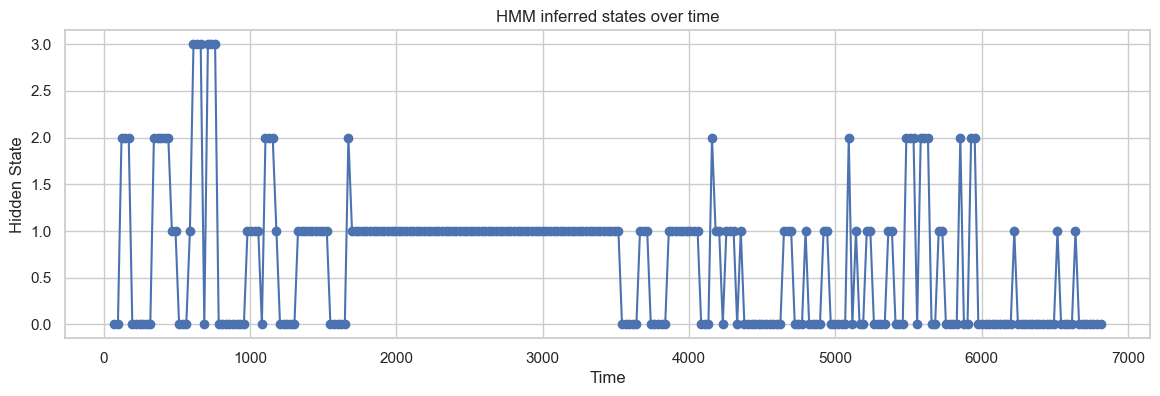

In [67]:
plt.figure(figsize=(14,4))
plt.plot(features2["start_time"], hidden_states, marker='o')
plt.xlabel("Time")
plt.ylabel("Hidden State")
plt.title("HMM inferred states over time")
plt.show()

In [68]:
print(hmm_model.transmat_)

[[8.06377148e-001 1.08429333e-001 7.74486535e-002 7.74486536e-003]
 [1.38071976e-001 8.53298570e-001 4.66168916e-135 8.62945323e-003]
 [3.04351012e-001 1.30431597e-001 5.65217391e-001 0.00000000e+000]
 [3.33333333e-001 4.57301719e-053 0.00000000e+000 6.66666667e-001]]


---

# Detected patterns

In [69]:
min_len = min(len(features2), len(cluster_labels), len(hidden_states))

features2_aligned = features2.iloc[:min_len].copy()

features2_aligned["cluster"] = cluster_labels[:min_len]
features2_aligned["hmm_state"] = hidden_states[:min_len]

detected_patterns = features2_aligned[
    ["window_id", "start_idx", "start_time", "cluster", "hmm_state"]
].copy()

detected_patterns.head()

,window_id,start_idx,start_time,cluster,hmm_state
3,3,60,73.767,1,0
4,4,80,98.356,0,0
5,5,100,122.945,0,2
6,6,120,147.533,0,2
7,7,140,172.122,0,2


In [70]:
print("features2:", len(features2))
print("cluster_labels:", len(cluster_labels))
print("hidden_states:", len(hidden_states))
print("X_scaled:", X_scaled.shape)
print("X_hmm:", X_hmm.shape)

features2: 275
cluster_labels: 278
hidden_states: 275
X_scaled: (275, 48)
X_hmm: (275, 48)


In [71]:
detected_patterns["cluster_pattern_name"] = detected_patterns["cluster"].map({
    0: "baseline",
    1: "active_fluctuation",
    2: "oscillation",
    3: "burst_spike"
})

detected_patterns["hmm_state_name"] = detected_patterns["hmm_state"].map({
    0: "resting",
    1: "active",
    2: "burst_event",
    3: "transition"
})

detected_patterns.head(20)

,window_id,start_idx,start_time,cluster,hmm_state,cluster_pattern_name,hmm_state_name
3,3,60,73.767,1,0,active_fluctuation,resting
4,4,80,98.356,0,0,baseline,resting
5,5,100,122.945,0,2,baseline,burst_event
6,6,120,147.533,0,2,baseline,burst_event
7,7,140,172.122,0,2,baseline,burst_event
8,8,160,196.710,0,0,baseline,resting
9,9,180,221.298,0,0,baseline,resting
10,10,200,245.886,0,0,baseline,resting
11,11,220,270.476,0,0,baseline,resting
12,12,240,295.066,0,0,baseline,resting


totally window3-277， only show the first 5

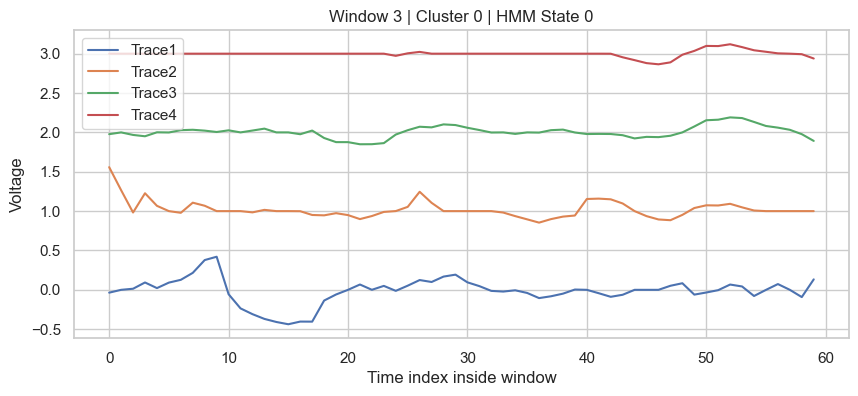

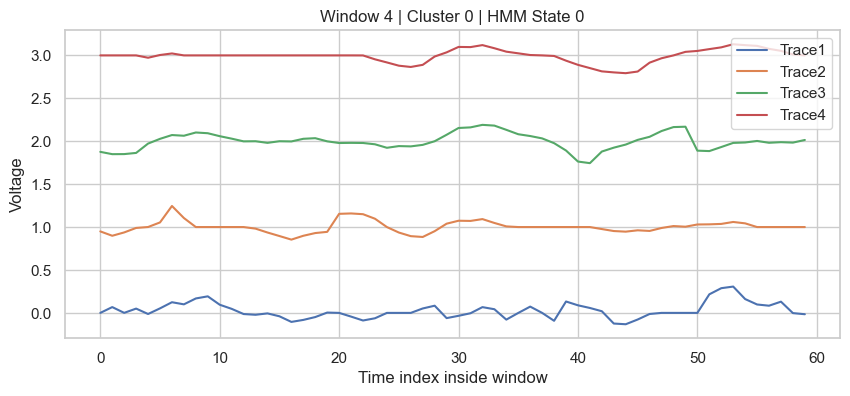

In [72]:
import os

output_dir = "detected_patterns_plots"
os.makedirs(output_dir, exist_ok=True)

max_plots = 5

for i, row in features2.iterrows():
    if i >= max_plots:
        break

    window_id = int(row["window_id"])
    cluster = int(row["cluster"])
    hmm_state = int(row["hmm_state"])

    pattern_window = windows[window_id]

    plt.figure(figsize=(10, 4))

    for ch in range(pattern_window.shape[1]):
        plt.plot(pattern_window[:, ch], label=f"Trace{ch+1}")

    plt.title(
        f"Window {window_id} | Cluster {cluster} | HMM State {hmm_state}"
    )
    plt.xlabel("Time index inside window")
    plt.ylabel("Voltage")
    plt.legend()
    plt.grid(True)

    filename = f"window_{window_id}_cluster_{cluster}_hmm_{hmm_state}.png"
    filepath = os.path.join(output_dir, filename)

    plt.savefig(filepath, dpi=300, bbox_inches="tight")
    plt.show()

In [73]:
def build_pattern_segments(features_df, label_col="cluster"):
    df_seg = features_df.copy().reset_index(drop=True)

    # when the patterns change
    df_seg["segment_id"] = (
        df_seg[label_col] != df_seg[label_col].shift()
    ).cumsum()

    segments = []

    for seg_id, group in df_seg.groupby("segment_id"):
        start_window = int(group["window_id"].iloc[0])
        end_window = int(group["window_id"].iloc[-1])

        start_idx = int(group["start_idx"].iloc[0])

        # each window length 60
        end_idx = int(group["start_idx"].iloc[-1] + 60)

        segments.append({
            "segment_id": int(seg_id),
            "label_type": label_col,
            "pattern_label": int(group[label_col].iloc[0]),
            "start_window": start_window,
            "end_window": end_window,
            "start_idx": start_idx,
            "end_idx": end_idx,
            "start_time": float(group["start_time"].iloc[0]),
            "num_windows": len(group)
        })

    return pd.DataFrame(segments)

In [74]:
cluster_segments = build_pattern_segments(
    features2_aligned,
    label_col="cluster"
)

cluster_segments.head(20)

,segment_id,label_type,pattern_label,start_window,end_window,start_idx,end_idx,start_time,num_windows
0,1,cluster,1,3,3,60,120,73.767,1
1,2,cluster,0,4,277,80,5600,98.356,274


In [75]:
hmm_segments = build_pattern_segments(
    features2_aligned,
    label_col="hmm_state"
)

hmm_segments.head(20)

,segment_id,label_type,pattern_label,start_window,end_window,start_idx,end_idx,start_time,num_windows
0,1,hmm_state,0,3,4,60,140,73.767,2
1,2,hmm_state,2,5,7,100,200,122.945,3
2,3,hmm_state,0,8,13,160,320,196.710,6
3,4,hmm_state,2,14,18,280,420,344.262,5
4,5,hmm_state,1,19,20,380,460,467.230,2
5,6,hmm_state,0,21,23,420,520,516.408,3
6,7,hmm_state,1,24,24,480,540,590.175,1
7,8,hmm_state,3,25,27,500,600,614.764,3
8,9,hmm_state,0,28,28,560,620,688.563,1
9,10,hmm_state,3,29,31,580,680,713.151,3


In [76]:
def plot_pattern_segments(signal_data, segments_df, output_dir="pattern_segments"):
    os.makedirs(output_dir, exist_ok=True)

    for i, row in segments_df.iterrows():
        if i >= max_plots: 
            break
        segment_id = int(row["segment_id"])
        label_type = row["label_type"]
        pattern_label = int(row["pattern_label"])
        start_idx = int(row["start_idx"])
        end_idx = int(row["end_idx"])

        segment_signal = signal_data[start_idx:end_idx]

        plt.figure(figsize=(10, 4))

        for ch in range(segment_signal.shape[1]):
            plt.plot(segment_signal[:, ch], label=f"Trace{ch+1}")

        plt.title(
            f"Segment {segment_id} | {label_type} {pattern_label} | "
            f"Window {row['start_window']}–{row['end_window']}"
        )
        plt.xlabel("Time index inside detected pattern segment")
        plt.ylabel("Voltage")
        plt.legend()
        plt.grid(True)

        filename = f"segment_{segment_id}_{label_type}_{pattern_label}.png"
        filepath = os.path.join(output_dir, filename)

        plt.savefig(filepath, dpi=300, bbox_inches="tight")
        plt.show()

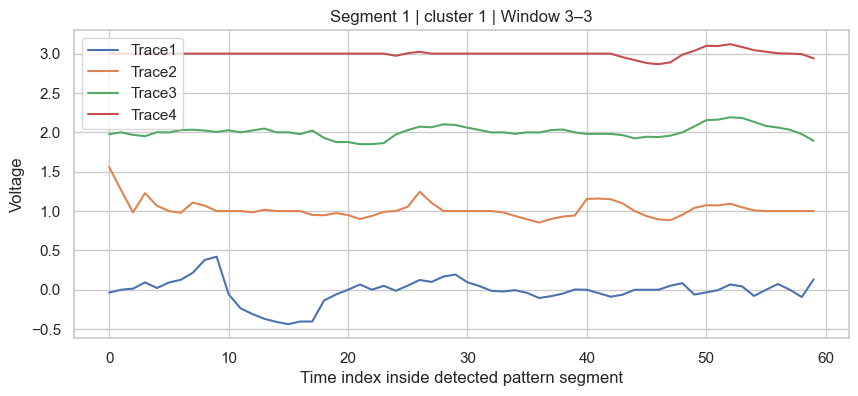

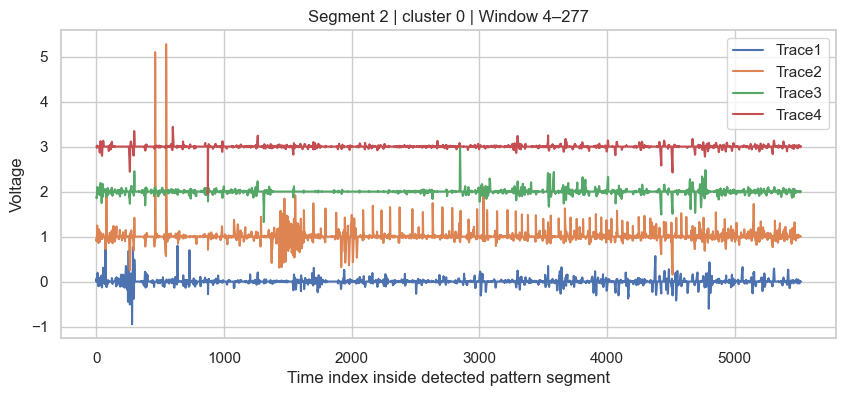

In [77]:
signal_data = df2[["D21 Trace1", "D21 Trace2", "D21 Trace3", "D21 Trace4"]].values

plot_pattern_segments(
    signal_data,
    cluster_segments,
    output_dir="cluster_pattern_segments"
)

totally 62 plots，only see the first 5

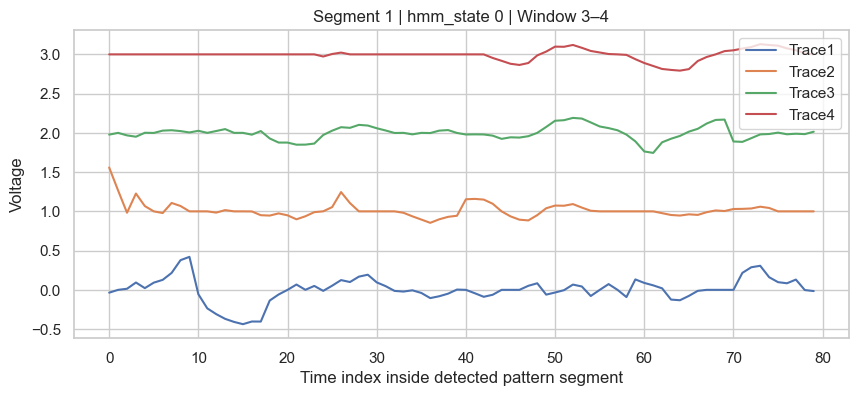

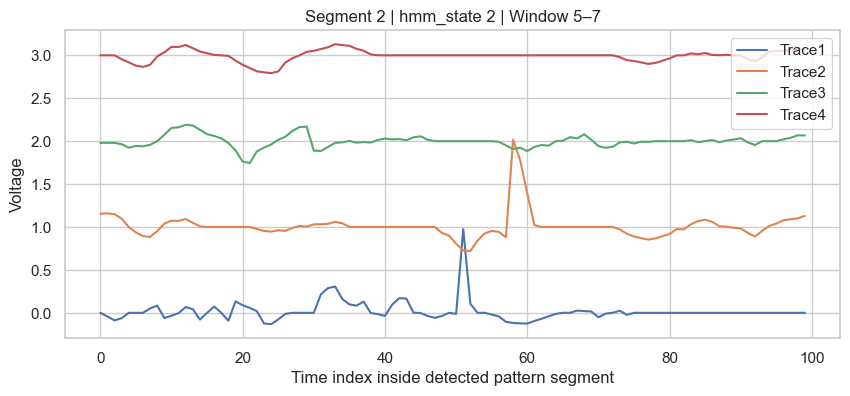

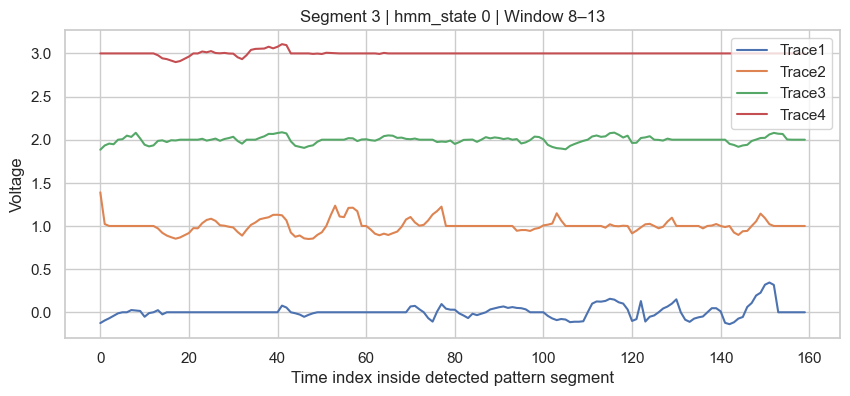

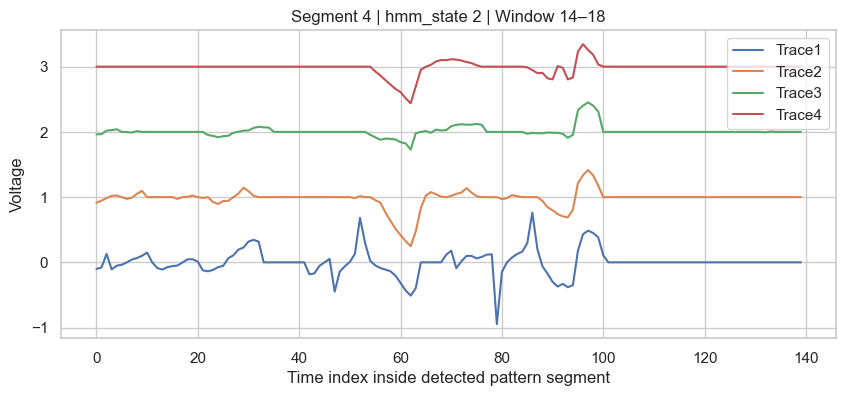

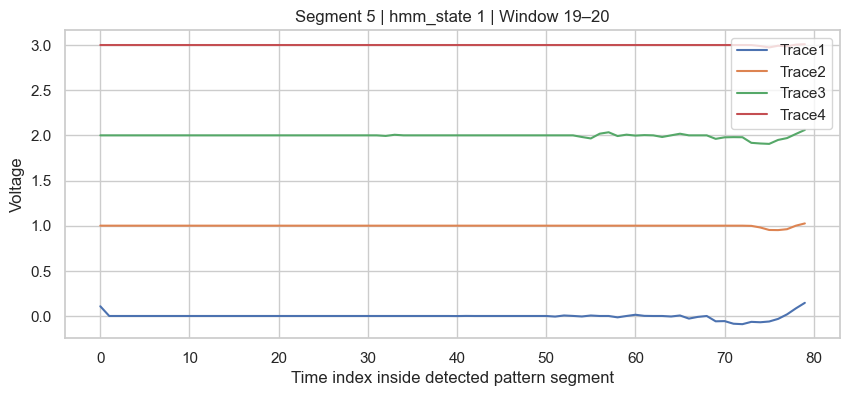

In [78]:
plot_pattern_segments(
    signal_data,
    hmm_segments,
    output_dir="hmm_pattern_segments",
)

---

## Try diag Cov

In [79]:
X_hmm = X_scaled

model = GaussianHMM(
    n_components=4,
    covariance_type='diag',
    n_iter=300,
    random_state=42
)

model.fit(X_hmm)
hidden_states = model.predict(X_hmm)

features2["hmm_state"] = hidden_states
print(features2[["window_id", "start_time", "hmm_state"]].head(20))

    window_id  start_time  hmm_state
3           3      73.767          2
4           4      98.356          0
5           5     122.945          2
6           6     147.533          2
7           7     172.122          2
8           8     196.710          0
9           9     221.298          1
10         10     245.886          1
11         11     270.476          1
12         12     295.066          0
13         13     319.655          0
14         14     344.262          2
15         15     368.851          2
16         16     393.440          2
17         17     418.029          2
18         18     442.640          2
19         19     467.230          1
20         20     491.819          1
21         21     516.408          0
22         22     540.997          0


States continue for a while.

In [80]:
print(np.bincount(hidden_states))

[114 120  35   6]


But not distributed evenly

In [81]:
features2["hmm_state"] = hidden_states

print(features2.groupby("hmm_state").mean().T)

hmm_state                                       0            1            2  \
D21 Trace1_spike_count                   1.482456     2.033333     1.685714   
D21 Trace1_pos_spike_count               0.833333     1.025000     0.742857   
D21 Trace1_neg_spike_count               0.649123     1.008333     0.942857   
D21 Trace1_max_amplitude                 0.220221     0.105717     0.453816   
D21 Trace1_mean_spike_height             0.209039     0.093403     0.424592   
D21 Trace1_mean_inter_spike_interval     5.280702     9.170139     7.257143   
D21 Trace1_mean                         -0.000801    -0.000692    -0.004825   
D21 Trace1_std                           0.070680     0.030128     0.117390   
D21 Trace1_range                         0.363421     0.175930     0.700063   
D21 Trace1_slope                         0.000074    -0.000053    -0.000296   
D21 Trace1_energy                        0.385391     0.072695     1.065188   
D21 Trace1_fft_dominant_frequency        0.037472   

In Trace1: state 1 more like spike-active.   
State0 = Baseline / Resting state -- lowest std.  
State1 = Highest Spike count sometimes-some channels.  Moderate active state    
State2 = highest energy (Strong activation state/High-energy burst state) Trace1 spike highest. Selective burst state, like bioelectric burst.  
  
Signal has three latent operating regimes:
1. Resting
2. Active
3. Burst/Event

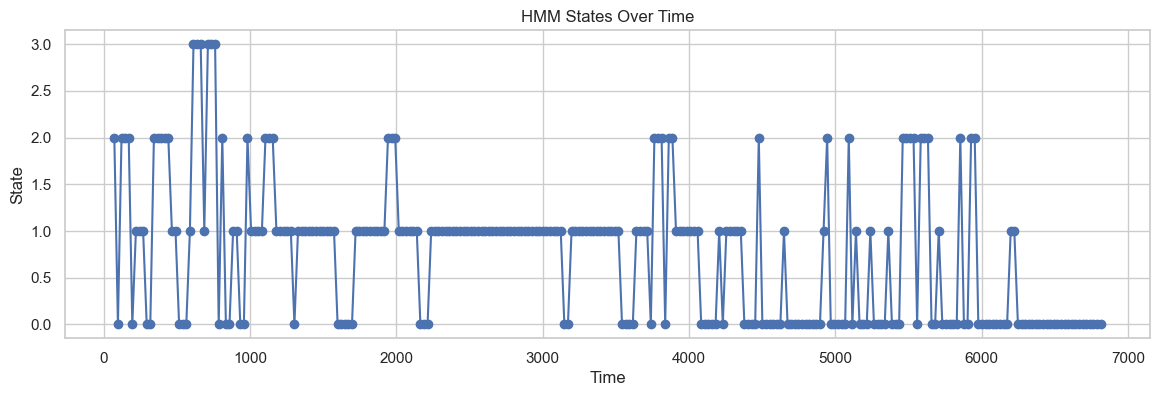

In [82]:
plt.figure(figsize=(14,4))
plt.plot(features2["start_time"], hidden_states, marker='o')
plt.xlabel("Time")
plt.ylabel("State")
plt.title("HMM States Over Time")
plt.show()

<Axes: >

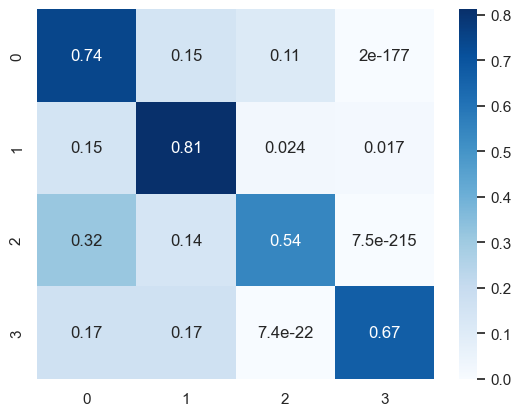

In [83]:
sns.heatmap(model.transmat_, annot=True, cmap="Blues")

0 → 0 = 0.89  
0 → 1 = 0.10  
0 → 2 = 0.005  
If we are currently in State 0:  
89% will remain at State 0  
10% will move to State 1  
It's highly unlikely that we'll jump directly to State 2.  
**The baseline is very stable** and will not suddenly change. It typically goes through transition state 1 first, and then changes.
  
  
1 → 1 = 0.72  
1 → 0 = 0.27  
1 → 2 = 0.014  
If we are currently in State 1:
mostly continue state 1  
nomally back to 0  
seldomly change into state 2  

2 → 2 = 0.60
2 → 1 = 0.40
2 → 0 ≈ 0
If we are currently in State 2:
60% continues to burst  
40% drops to state 1  
It almost never returns to 0 directly.   
2 → 1 → 0

---  
# Predict Patterns - LSTM  
To predict the next pattern, use LSTM.   
To capture spikes or local waveform features, use CNN.  
features: original window patterns + cluster + hmm_state

In [84]:
# Predict the next pattern using the number of past windows
seq_len = 10

# y represents the next cluster, which is the next pattern.
features2["next_pattern"] = features2["cluster"].shift(-1)

# Remove the last line because it doesn't contain `next_pattern`.
df1 = features2.dropna(subset=["next_pattern"]).copy()
df1["next_pattern"] = df1["next_pattern"].astype(int)

meta_cols = ["window_id", "start_idx", "start_time", "next_pattern"]
feature_cols = [c for c in df1.columns if c not in meta_cols]

selected_features = [
    "cluster",                         # specific pattern type
    "D21 Trace1_max_amplitude",
    "D21 Trace1_mean_inter_spike_interval",
    "D21 Trace1_fft_dominant_frequency"
]

X_raw = df1[selected_features].values
y_raw = df1["next_pattern"].values
# X_raw = df1[feature_cols].values
# y_raw = df1["next_pattern"].values

### LSTM sequence

In [85]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_raw)

def create_sequences(X, y, seq_len=10):
    X_seq = []
    y_seq = []

    for i in range(len(X) - seq_len):
        X_seq.append(X[i:i+seq_len])
        y_seq.append(y[i+seq_len-1])

    return np.array(X_seq), np.array(y_seq)

X_seq, y_seq = create_sequences(X_scaled, y_raw, seq_len)

print(X_seq.shape)
print(y_seq.shape)

(264, 10, 4)
(264,)


In [86]:
# Split databset = train, test, validation
n = len(X_seq)

train_end = int(n * 0.7)
val_end = int(n * 0.85)

X_train = X_seq[:train_end]
y_train = y_seq[:train_end]

X_val = X_seq[train_end:val_end]
y_val = y_seq[train_end:val_end]

X_test = X_seq[val_end:]
y_test = y_seq[val_end:]

print("Train:", X_train.shape)
print("Val:", X_val.shape)
print("Test:", X_test.shape)

Train: (184, 10, 4)
Val: (40, 10, 4)
Test: (40, 10, 4)


X_seq[0] = 1st-10th windw  
y_seq[0] = 11th window pattern

In [87]:
import torch
import torch.nn as nn
from torch.utils.data import TensorDataset, DataLoader

X_tensor = torch.tensor(X_seq, dtype=torch.float32)
y_tensor = torch.tensor(y_seq, dtype=torch.long)

train_dataset = TensorDataset(
    torch.tensor(X_train, dtype=torch.float32),
    torch.tensor(y_train, dtype=torch.long)
)

val_dataset = TensorDataset(
    torch.tensor(X_val, dtype=torch.float32),
    torch.tensor(y_val, dtype=torch.long)
)

test_dataset = TensorDataset(
    torch.tensor(X_test, dtype=torch.float32),
    torch.tensor(y_test, dtype=torch.long)
)

train_loader = DataLoader(train_dataset, batch_size=16, shuffle=False)
val_loader = DataLoader(val_dataset, batch_size=16, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=16, shuffle=False)

In [88]:
class PatternLSTM(nn.Module):
    def __init__(self, input_size, hidden_size, num_classes):
        super().__init__()

        self.lstm = nn.LSTM(
            input_size=input_size,
            hidden_size=hidden_size,
            batch_first=True
        )

        self.dropout = nn.Dropout(0.3)    # dropout +
        self.fc = nn.Linear(hidden_size, num_classes)

    def forward(self, x):
        out, _ = self.lstm(x)
        last_out = out[:, -1, :]
        last_out = self.dropout(last_out)   # dropout +
        return self.fc(last_out)

use class weight loss function -> model more focus on rare pattern(spike/burst)

In [89]:
# Training with fixed train/validation split

#  from sklearn.utils.class_weight import compute_class_weight
# input_size = X_seq.shape[2]
# hidden_size = 32
# num_classes = len(np.unique(y_seq))

# model = PatternLSTM(input_size, hidden_size, num_classes)


# classes = np.unique(y_seq)
# class_weights = compute_class_weight(
#     class_weight='balanced',
#     classes=classes,
#     y=y_seq
# )

# class_weights = torch.tensor(class_weights, dtype=torch.float32)

# criterion = nn.CrossEntropyLoss(weight=class_weights)
# # criterion = nn.CrossEntropyLoss()
# optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

# epochs = 50

# train_losses = []
# val_losses = []

# for epoch in range(epochs):
#     # -------- train --------
#     model.train()
#     total_loss = 0

#     for batch_X, batch_y in train_loader:
#         optimizer.zero_grad()
#         outputs = model(batch_X)
#         loss = criterion(outputs, batch_y)
#         loss.backward()
#         optimizer.step()
#         total_loss += loss.item()

#     train_loss = total_loss / len(train_loader)

#     # -------- validation --------
#     model.eval()
#     val_loss = 0

#     with torch.no_grad():
#         for batch_X, batch_y in val_loader:
#             outputs = model(batch_X)
#             loss = criterion(outputs, batch_y)
#             val_loss += loss.item()

#     val_loss = val_loss / len(val_loader)

#     train_losses.append(train_loss)
#     val_losses.append(val_loss)

#     print(f"Epoch {epoch+1}: Train Loss={train_loss:.4f}, Val Loss={val_loss:.4f}")

### K fold  
Each fold in a K-fold should have its model reinitialized:  
`model = PatternLSTM(input_size, hidden_size, num_classes)`  
Time-series cross-validation was used for model validation to avoid relying on a single train-validation split.
Each fold reinitialised the LSTM model to prevent data leakage.

In [90]:
# Use K fold - train with multiple train/validation splits
from sklearn.model_selection import TimeSeriesSplit
from sklearn.metrics import accuracy_score, fbeta_score
from sklearn.utils.class_weight import compute_class_weight
import numpy as np
import torch
from torch.utils.data import TensorDataset, DataLoader

tscv = TimeSeriesSplit(n_splits=5)

fold_results = []

input_size = X_seq.shape[2]
hidden_size = 16
num_classes = len(np.unique(y_seq))

epochs = 20

for fold, (train_idx, val_idx) in enumerate(tscv.split(X_seq)):
    print(f"\n===== Fold {fold + 1} =====")

    X_train, X_val = X_seq[train_idx], X_seq[val_idx]
    y_train, y_val = y_seq[train_idx], y_seq[val_idx]

    train_dataset = TensorDataset(
        torch.tensor(X_train, dtype=torch.float32),
        torch.tensor(y_train, dtype=torch.long)
    )

    val_dataset = TensorDataset(
        torch.tensor(X_val, dtype=torch.float32),
        torch.tensor(y_val, dtype=torch.long)
    )

    train_loader = DataLoader(train_dataset, batch_size=16, shuffle=False)
    val_loader = DataLoader(val_dataset, batch_size=16, shuffle=False)

    # The model must be reinitialized for each fold.
    model = PatternLSTM(input_size, hidden_size, num_classes)

    # Class weight is calculated using only the train label of the current fold.
    classes = np.unique(y_train)
    class_weights = compute_class_weight(
        class_weight="balanced",
        classes=classes,
        y=y_train
    )

    full_weights = np.ones(num_classes)
    for c, w in zip(classes, class_weights):
        full_weights[int(c)] = w

    class_weights_tensor = torch.tensor(full_weights, dtype=torch.float32)

    criterion = nn.CrossEntropyLoss(weight=class_weights_tensor)

    optimizer = torch.optim.Adam(
        model.parameters(),
        lr=0.001,
        weight_decay=1e-4
    )

    train_losses = []
    val_losses = []

    for epoch in range(epochs):
        model.train()
        total_loss = 0

        for batch_X, batch_y in train_loader:
            optimizer.zero_grad()
            outputs = model(batch_X)
            loss = criterion(outputs, batch_y)
            loss.backward()
            optimizer.step()
            total_loss += loss.item()

        train_loss = total_loss / len(train_loader)

        model.eval()
        val_loss = 0
        y_true = []
        y_pred = []

        with torch.no_grad():
            for batch_X, batch_y in val_loader:
                outputs = model(batch_X)
                loss = criterion(outputs, batch_y)
                val_loss += loss.item()

                preds = torch.argmax(outputs, dim=1)
                y_true.extend(batch_y.numpy())
                y_pred.extend(preds.numpy())

        val_loss = val_loss / len(val_loader)

        train_losses.append(train_loss)
        val_losses.append(val_loss)

    acc = accuracy_score(y_true, y_pred)
    f2 = fbeta_score(y_true, y_pred, beta=2, average="weighted", zero_division=0)

    fold_results.append({
        "fold": fold + 1,
        "accuracy": acc,
        "f2_score": f2,
        "final_train_loss": train_losses[-1],
        "final_val_loss": val_losses[-1]
    })

    print(f"Fold {fold+1} Accuracy: {acc:.4f}")
    print(f"Fold {fold+1} F2 Score: {f2:.4f}")
    print(f"Final Train Loss: {train_losses[-1]:.4f}")
    print(f"Final Val Loss: {val_losses[-1]:.4f}")


===== Fold 1 =====
Fold 1 Accuracy: 0.8636
Fold 1 F2 Score: 0.8679
Final Train Loss: 1.3024
Final Val Loss: 1.2653

===== Fold 2 =====
Fold 2 Accuracy: 0.9318
Fold 2 F2 Score: 0.9184
Final Train Loss: 1.1735
Final Val Loss: 1.0849

===== Fold 3 =====
Fold 3 Accuracy: 0.5455
Fold 3 F2 Score: 0.4675
Final Train Loss: 1.1014
Final Val Loss: 1.1296

===== Fold 4 =====
Fold 4 Accuracy: 0.3636
Fold 4 F2 Score: 0.3506
Final Train Loss: 0.9290
Final Val Loss: 1.3309

===== Fold 5 =====
Fold 5 Accuracy: 0.6364
Fold 5 F2 Score: 0.6212
Final Train Loss: 0.8735
Final Val Loss: 0.9584


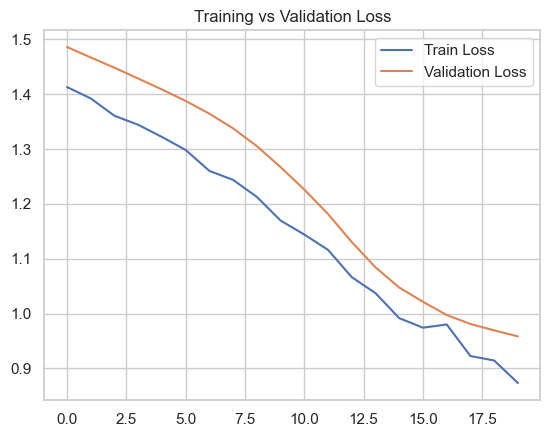

In [91]:
# plot loss

plt.plot(train_losses, label="Train Loss")
plt.plot(val_losses, label="Validation Loss")
plt.legend()
plt.title("Training vs Validation Loss")
plt.show()

The training loss decreases steadily, while the validation loss
increases over time, indicating that the model is overfitting.

This suggests that the model is learning patterns specific to the
training data but fails to generalise to unseen data.

Version 1 result(added parameters for LSTM): more epoch more overfit  
<img src="output1.png" width="450">  

Version 2 result (added dropout 0.3): still overfit   
<img src="output2.png" width="450">  

Version 3 add K fold:  
- More efficient use of data (each segment has been validated)
- Avoids the randomness of "just getting good/bad data"
-  A more stable training process     

<img src="output3.png" width="450">

Version 4 only k fold:  
<img src="output4.png" width="450">

---
# Evaluation

In [92]:
from sklearn.metrics import accuracy_score

model.eval()
y_pred = []
y_true = []

# with torch.no_grad():
# #     logits = model(X_tensor)
# #     predicted_pattern = torch.argmax(logits, dim=1).numpy()

# # result_df = features2.iloc[seq_len:seq_len + len(predicted_pattern)].copy()
# # result_df["predicted_next_pattern"] = predicted_pattern

# # result_df[["cluster", "predicted_next_pattern"]].head(20)
#     for X_batch, y_batch in test_loader:
#         outputs = model(X_batch)
#         preds = torch.argmax(outputs, dim=1)

#         y_pred.extend(preds.numpy())
#         y_true.extend(y_batch.numpy())

# acc = accuracy_score(y_true, y_pred)
# print("Accuracy:", acc)

results_df = pd.DataFrame(fold_results)
display(results_df)

print("Average Accuracy:", results_df["accuracy"].mean())
print("Average F2 Score:", results_df["f2_score"].mean())

,fold,accuracy,f2_score,final_train_loss,final_val_loss
0,1,0.863636,0.867870,1.302445,1.265306
1,2,0.931818,0.918378,1.173484,1.084880
2,3,0.545455,0.467532,1.101366,1.129561
3,4,0.363636,0.350570,0.928982,1.330896
4,5,0.636364,0.621193,0.873461,0.958424


Average Accuracy: 0.6681818181818182
Average F2 Score: 0.6451088392982418


In [93]:
# from sklearn.metrics import fbeta_score

# f2 = fbeta_score(y_true, y_pred, beta=2, average='weighted')
# print("F2 score:", f2)

F2 more focus recall(whether find rare pattern--spike/burst)

In [94]:
# # Confusion Matrix
# from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
# import matplotlib.pyplot as plt

# cm = confusion_matrix(y_true, y_pred)

# disp = ConfusionMatrixDisplay(cm)
# disp.plot()
# plt.show()

The model can recognize the baseline, but its ability to recognize complex/rare patterns is weak.

---

# II. Data-Normalization

Use detrend data provided as df2.

In [95]:
signal1 = df2["D21 Trace1"]  
signal2 = df2["D21 Trace2"]  
signal3 = df2["D21 Trace3"]  
signal4 = df2["D21 Trace4"]  

In [96]:
df2.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5615 entries, 0 to 5614
Data columns (total 20 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   index              5615 non-null   int64  
 1   date               1 non-null      object 
 2   time (from start)  5615 non-null   float64
 3   Normalized data    3 non-null      object 
 4   N5616 Trace1       5615 non-null   float64
 5   N5616 Trace2       5615 non-null   float64
 6   N5616 Trace3       5615 non-null   float64
 7   N5616 Trace4       5615 non-null   float64
 8   Detrend            7 non-null      object 
 9   Min index row      5615 non-null   int64  
 10  max index row      5615 non-null   int64  
 11  D21 Trace1         5615 non-null   float64
 12  D21 Trace2         5615 non-null   float64
 13  D21 Trace3         5615 non-null   float64
 14  D21 Trace4         5615 non-null   float64
 15  offset             0 non-null      float64
 16  0                  0 non

In [97]:
df2.head(10)

,index,date,time (from start),Normalized data,N5616 Trace1,N5616 Trace2,N5616 Trace3,N5616 Trace4,Detrend,Min index row,max index row,D21 Trace1,D21 Trace2,D21 Trace3,D21 Trace4,offset,0,1,2,3
0,1,2026-03-13,0.000,N,26.909180,56.684570,61.666504,37.591309,D,2,12,-2.608643,-0.781250,-0.182373,1.212647,NaN,NaN,NaN,NaN,NaN
1,2,NaN,1.233,NaN,28.104493,57.648193,62.696533,38.512940,(window size),2,13,-1.462036,0.183472,0.788941,2.160889,NaN,NaN,NaN,NaN,NaN
2,3,NaN,2.462,NaN,28.828369,58.076416,63.165283,38.932129,-10,2,14,-0.786866,0.612793,1.198975,2.606689,NaN,NaN,NaN,NaN,NaN
3,4,NaN,3.691,NaN,29.210450,58.324707,63.526611,39.170166,21,2,15,-0.479736,0.894531,1.519409,2.859497,NaN,NaN,NaN,NaN,NaN
4,5,NaN,4.920,NaN,29.340576,58.463623,63.728759,39.325440,NaN,2,16,-0.424561,1.066895,1.680664,3.029541,NaN,NaN,NaN,NaN,NaN
5,6,NaN,6.149,Max,29.517823,58.518310,63.848877,39.378662,Max,2,17,-0.296509,1.138427,1.791138,3.097533,NaN,NaN,NaN,NaN,NaN
6,7,NaN,7.379,5616,29.615235,58.537109,63.966308,39.416016,5616,2,18,-0.248291,1.174072,1.901855,3.149658,NaN,NaN,NaN,NaN,NaN
7,8,NaN,8.608,NaN,29.765137,58.514160,64.048095,39.418946,NaN,2,19,-0.165772,1.170288,1.991821,3.196411,NaN,NaN,NaN,NaN,NaN
8,9,NaN,9.839,NaN,29.863526,58.527587,64.130127,39.433594,Min and max manage end points,2,20,-0.134765,1.202880,2.082032,3.254883,NaN,NaN,NaN,NaN,NaN
9,10,NaN,11.068,NaN,29.998291,58.523681,64.159912,39.443360,NaN,2,21,0.067382,1.223388,2.125244,3.268921,NaN,NaN,NaN,NaN,NaN


In [98]:
df2.isnull().sum()

index                   0
date                 5614
time (from start)       0
Normalized data      5612
N5616 Trace1            0
N5616 Trace2            0
N5616 Trace3            0
N5616 Trace4            0
Detrend              5608
Min index row           0
max index row           0
D21 Trace1              0
D21 Trace2              0
D21 Trace3              0
D21 Trace4              0
offset               5615
0                    5615
1                    5615
2                    5615
3                    5615
dtype: int64

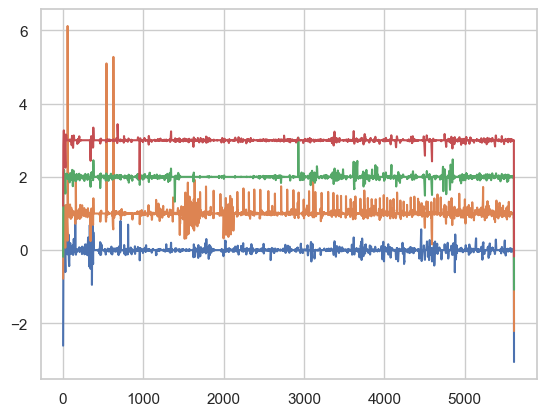

In [99]:
plt.plot(signal1)
plt.plot(signal2)
plt.plot(signal3)
plt.plot(signal4)

For signal analysis/machine learning: use detrend
For biological state research: trend can be retained as an auxiliary factor.

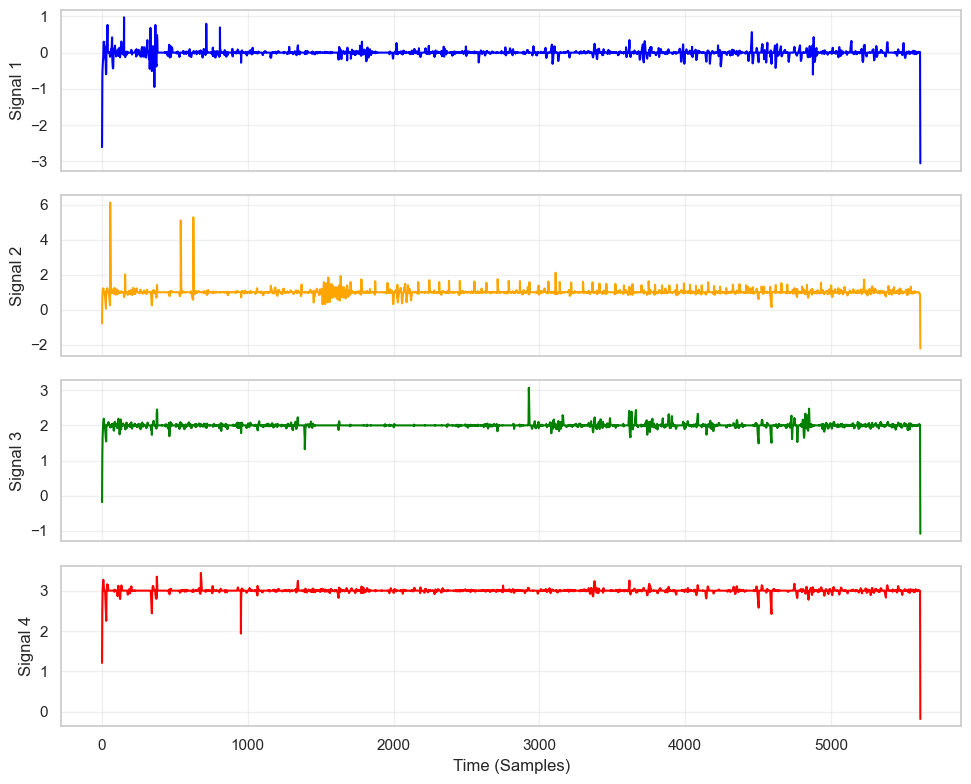

<Figure size 640x480 with 0 Axes>

In [100]:
signals = [signal1, signal2, signal3, signal4]
colors = ['blue', 'orange', 'green', 'red']
labels = ['Signal 1', 'Signal 2', 'Signal 3', 'Signal 4']

# Create a subgraph with 4 rows and 1 column.
fig, axs = plt.subplots(4, 1, figsize=(10, 8), sharex=True)

for i in range(4):
    axs[i].plot(signals[i], color=colors[i])
    axs[i].set_ylabel(labels[i])
    axs[i].grid(True, alpha=0.3)

plt.xlabel('Time (Samples)')
plt.tight_layout() # Automatically adjusts spacing to prevent label overlap.
plt.show()

plt.savefig('with_Normalized_data.png')

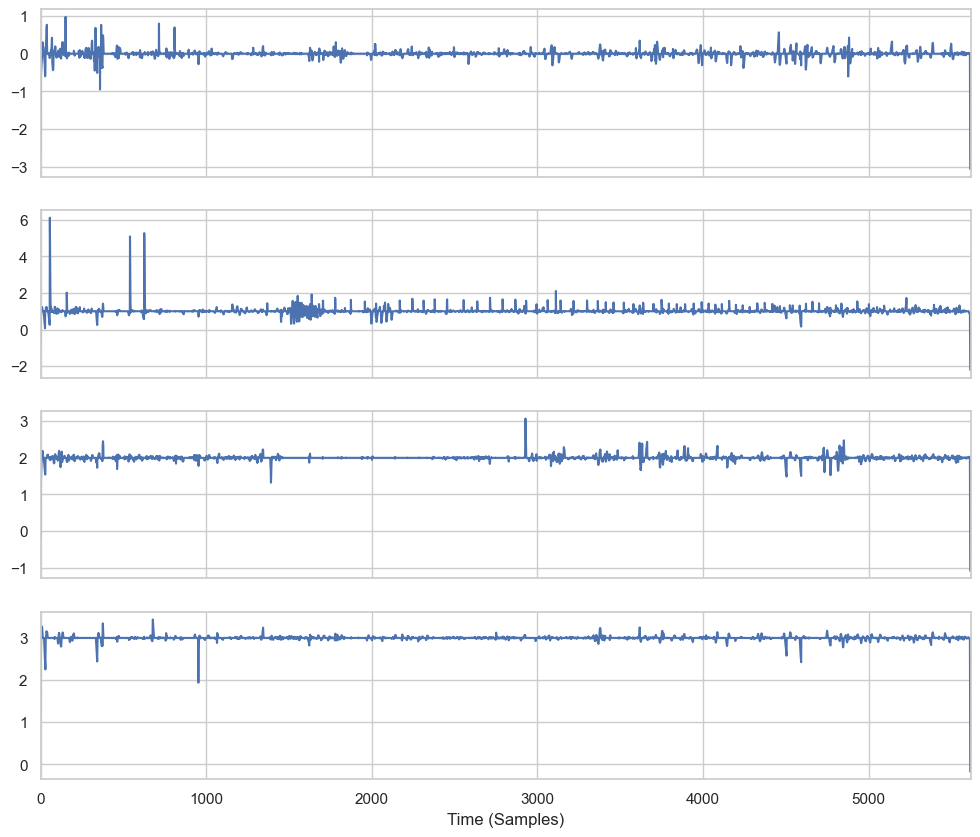

In [101]:
fig, axs = plt.subplots(4, 1, figsize=(12, 10), sharex=True)

for i in range(4):
    axs[i].plot(signals[i])
    # Set X-axis limits for each subplot
    axs[i].set_xlim(0, 5616) 

plt.xlabel("Time (Samples)")
plt.show()

Compare to normalization by myself in the previous part:
[My previous manual Normalization](#10)


。

---
# Save Model

In [102]:
import pickle

In [103]:
# save lstm
torch.save(model.state_dict(), "lstm_model.pth")

# save scaler
with open("scaler.pkl", "wb") as f:
    pickle.dump(scaler, f)

# save key info
config = {
    "seq_len": seq_len,
    "input_size": X_seq.shape[2],
    "hidden_size": 32,
    "num_classes": len(set(y_seq)),
    "feature_cols": feature_cols
}

with open("config.pkl", "wb") as f:
    pickle.dump(config, f)


# save hmm/clustering
with open("kmeans.pkl", "wb") as f:
    pickle.dump(kmeans, f)


In [104]:
with open("hmm_model.pkl", "wb") as f:
    pickle.dump(hmm_model, f)

In [105]:
# model
torch.save(model.state_dict(), "lstm_model.pth")

# scaler / config -- pkl
pickle.dump(scaler, open("scaler.pkl", "wb"))

---

# Research with papers published

https://pmc.ncbi.nlm.nih.gov/articles/PMC12483595/  
Detection of electrical signals in fungal mycelia in response to external stimuli

electrical activity correlated with fungal growth

Electrical signaling is a crucial mechanism for intercellular communication across diverse biological systems.

In this study, researched developed a novel approach using printed circuit boards with embedded differential electrodes to record extracellular voltage fluctuations in mycelium.
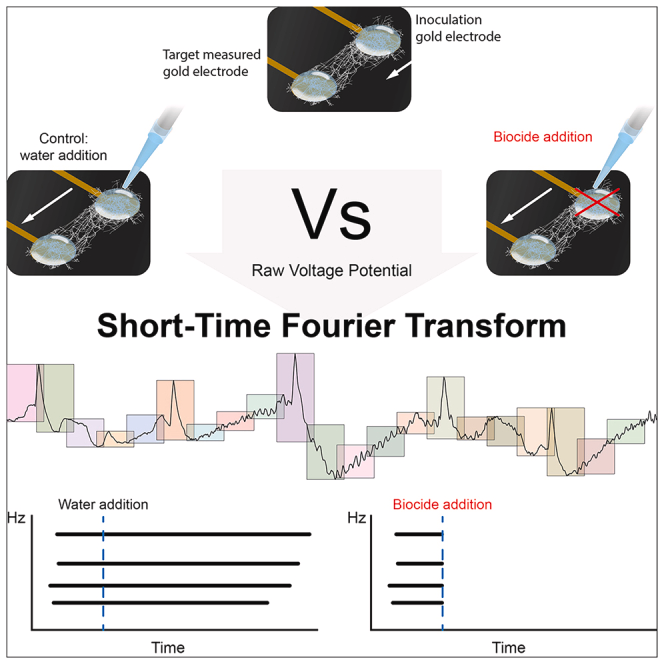

https://academic.oup.com/femsre/article/doi/10.1093/femsre/fuaf009/8090185#511922192

Electrical signaling is a fundamental mechanism for integrating environmental stimuli and coordinating responses in living organisms.  

For all living organisms, sensing environmental stimuli and integrating this information to generate a response are fundamental processes for survival. There are several mechanisms that organisms use for this coordination, including electrical signaling. Electrical signaling constitutes a rapid and reliable way of intra- and intercellular communication (Katz 1961, Keener and Sneyd 2009).  

action potentials are defined as a response to changes in voltage across the cell membrane, which result from ion (e.g. Na+, Ca2+, or K+) redistribution across the membrane. Depolarization that causes the cell to reach a certain voltage threshold generates a “spike” that is characteristic of these action potentials, which can then propagate along a cell and pass between adjacent cells (Häusser 2000).   

Reference:

1. Buffi M, Giangaspero S, Foiada V ...
Detection of electrical signals in fungal mycelia in response to external stimuli
iScience, 2025; 28